# Лабораторная работа №6. Методы агрегирования многомерных марковских процессов
Группа: ИУ5-81Б

№ по списку: 19

## Задание

$K$ программистов могут писать программы для выполнения на одном из $M$ серверов, при этом программа не попадает сразу на сервер, а обрабатывается на одном из $N$ специальных компьютеров, которые проверяют отсутствие вирусов. Интенсивность работы программистов $\lambda$, интенсивность работы компьютеров-антивирусов $\nu$, интенсивность работы основных серверов $\mu$, программа оказывается с вирусом с вероятностью $p$. Если программа с вирусом, она получает отказ обслуживания на основных серверах. Для компьютеров по проверке вирусов имеется ограничение по длине очереди $m_1$, для основных серверов ограничение по длине очереди $m_2$.

- Нарисовать граф состояний системы, учитывая количество программистов, которые пишут программу, количество программ на компьютерах-антивирусах, количество программ на серверах;
- Написать уравнения Колмогорова для вероятностей состояний, финальных вероятностей;
- Тремя способами (экспериментально с использованием пакета simmer, методом на основе параметров связи, теоретически по уравнениям Колмогорова) найти основные характеристики эффективности СМО: среднее время пребывания заявки в системе, абсолютную пропускную способность, среднее число заявок в системе.
- методом укрупнения состояний выполнить горизонтальное укрупнение, вертикальное укрупнение, сравнить полученные стационарные вероятности укрупненных состояний с вероятностями, полученным теоретически.
- исследовать, при каких значениях $m_1, m_2$  обеспечивается минимальное время пребывания заявки в системе с сохранением на заданном уровне абсолютной пропускной способности.

In [ ]:
Variant<-19
set.seed(Variant+864)
K<-sample(c(4:8),1)
M<-sample(c(2:5),1)
N<-sample(c(2:6),1)
lambda<-runif(1)
mu<-runif(1)
nu<-runif(1)
p<-runif(1,0,0.5)
m1<-sample(c(1:3),1)
m2<-sample(c(1:3),1)
View(data.frame(K,M,N,lambda,mu,nu,p,m1,m2))

K,M,N,lambda,mu,nu,p,m1,m2
<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
7,4,4,0.6054255,0.08142403,0.4713214,0.07394703,2,2


## Решение

### Граф состояний системы

Пусть система имеет следующие состояния:
$$S_{k,n,q_1,m,q_2},$$

где:
* $k = \overline{0, 7}$  − число активных программистов (т.е. разрабатывающих новую программу);
* $n = \overline{0, 4}$ - число программ, проходящих проверку на вирусы на антивирусных компьютерах;
* $q_1 = \overline{0, 2}$ - число программ, ожидающих проверку на вирусы в очереди;
* $m = \overline{0, 4}$ - число программ, исполняющихся на основных серверах;
* $q_2 = \overline{0, 2}$ - число программ, ожидающих исполнения на сервере в очереди.

*(Примечание: так как система замкнутая, общее число заявок в системе всегда равно количеству программистов, то есть $k + n + q_1 + m + q_2 = 7$)*

Построим граф состояний системы.


Вспомним **параметры  19 варианта**:
*   Всего программ/программистов в замкнутой системе: **$K = 7$**
*   Максимальная вместимость блока Антивирусов: **$N + m_1 = 4 + 2 = 6$ заявок** (4 проверяются + 2 в очереди)
*   Максимальная вместимость блока Серверов: **$M + m_2 = 4 + 2 = 6$ заявок** (4 исполняются + 2 в очереди)

Чтобы не путаться в пяти переменных $(k, n, q_1, m, q_2)$, давайте объединим их в логические блоки:
Пусть **$X$** — общее число заявок в блоке Антивирусов ($X = n + q_1$).
Пусть **$Y$** — общее число заявок в блоке Серверов ($Y = m + q_2$).

Мы знаем, что система замкнутая, значит общее количество заявок всегда равно 7:
$k + X + Y = 7$

Так как количество работающих программистов $k$ не может быть отрицательным ($k \ge 0$), из этого следует главное ограничение:
**$X + Y \le 7$**

Теперь давайте просто переберем все возможные комбинации $X$ и $Y$, помня о том, что $X$ не может быть больше 6, $Y$ не может быть больше 6, а их сумма не может быть больше 7.

*   Если в Антивирусах **$X = 0$** заявок: в Серверах $Y$ может быть от 0 до 6 $\rightarrow$ **7 состояний**
*   Если в Антивирусах **$X = 1$** заявка: в Серверах $Y$ может быть от 0 до 6 (т.к. 1+6=7) $\rightarrow$ **7 состояний**
*   Если в Антивирусах **$X = 2$** заявки: в Серверах $Y$ может быть от 0 до 5 (т.к. 2+5=7) $\rightarrow$ **6 состояний**
*   Если в Антивирусах **$X = 3$** заявки: в Серверах $Y$ может быть от 0 до 4 $\rightarrow$ **5 состояний**
*   Если в Антивирусах **$X = 4$** заявки: в Серверах $Y$ может быть от 0 до 3 $\rightarrow$ **4 состояния**
*   Если в Антивирусах **$X = 5$** заявок: в Серверах $Y$ может быть от 0 до 2 $\rightarrow$ **3 состояния**
*   Если в Антивирусах **$X = 6$** заявок: в Серверах $Y$ может быть от 0 до 1 $\rightarrow$ **2 состояния**

**Считаем сумму:**
7 + 7 + 6 + 5 + 4 + 3 + 2 = **34 состояния ровно**.

*(, зная только $X$ и $Y$, мы однозначно восстанавливаем полные состояния. Например, если $X=5$, мы точно знаем, что $n=4, q_1=1$, потому что сначала заполняются все 4 компьютера, а только потом 1 заявка встает в очередь.
Так что 34 состояния

[1] TRUE

Успешно сгенерировано состояний: 34 


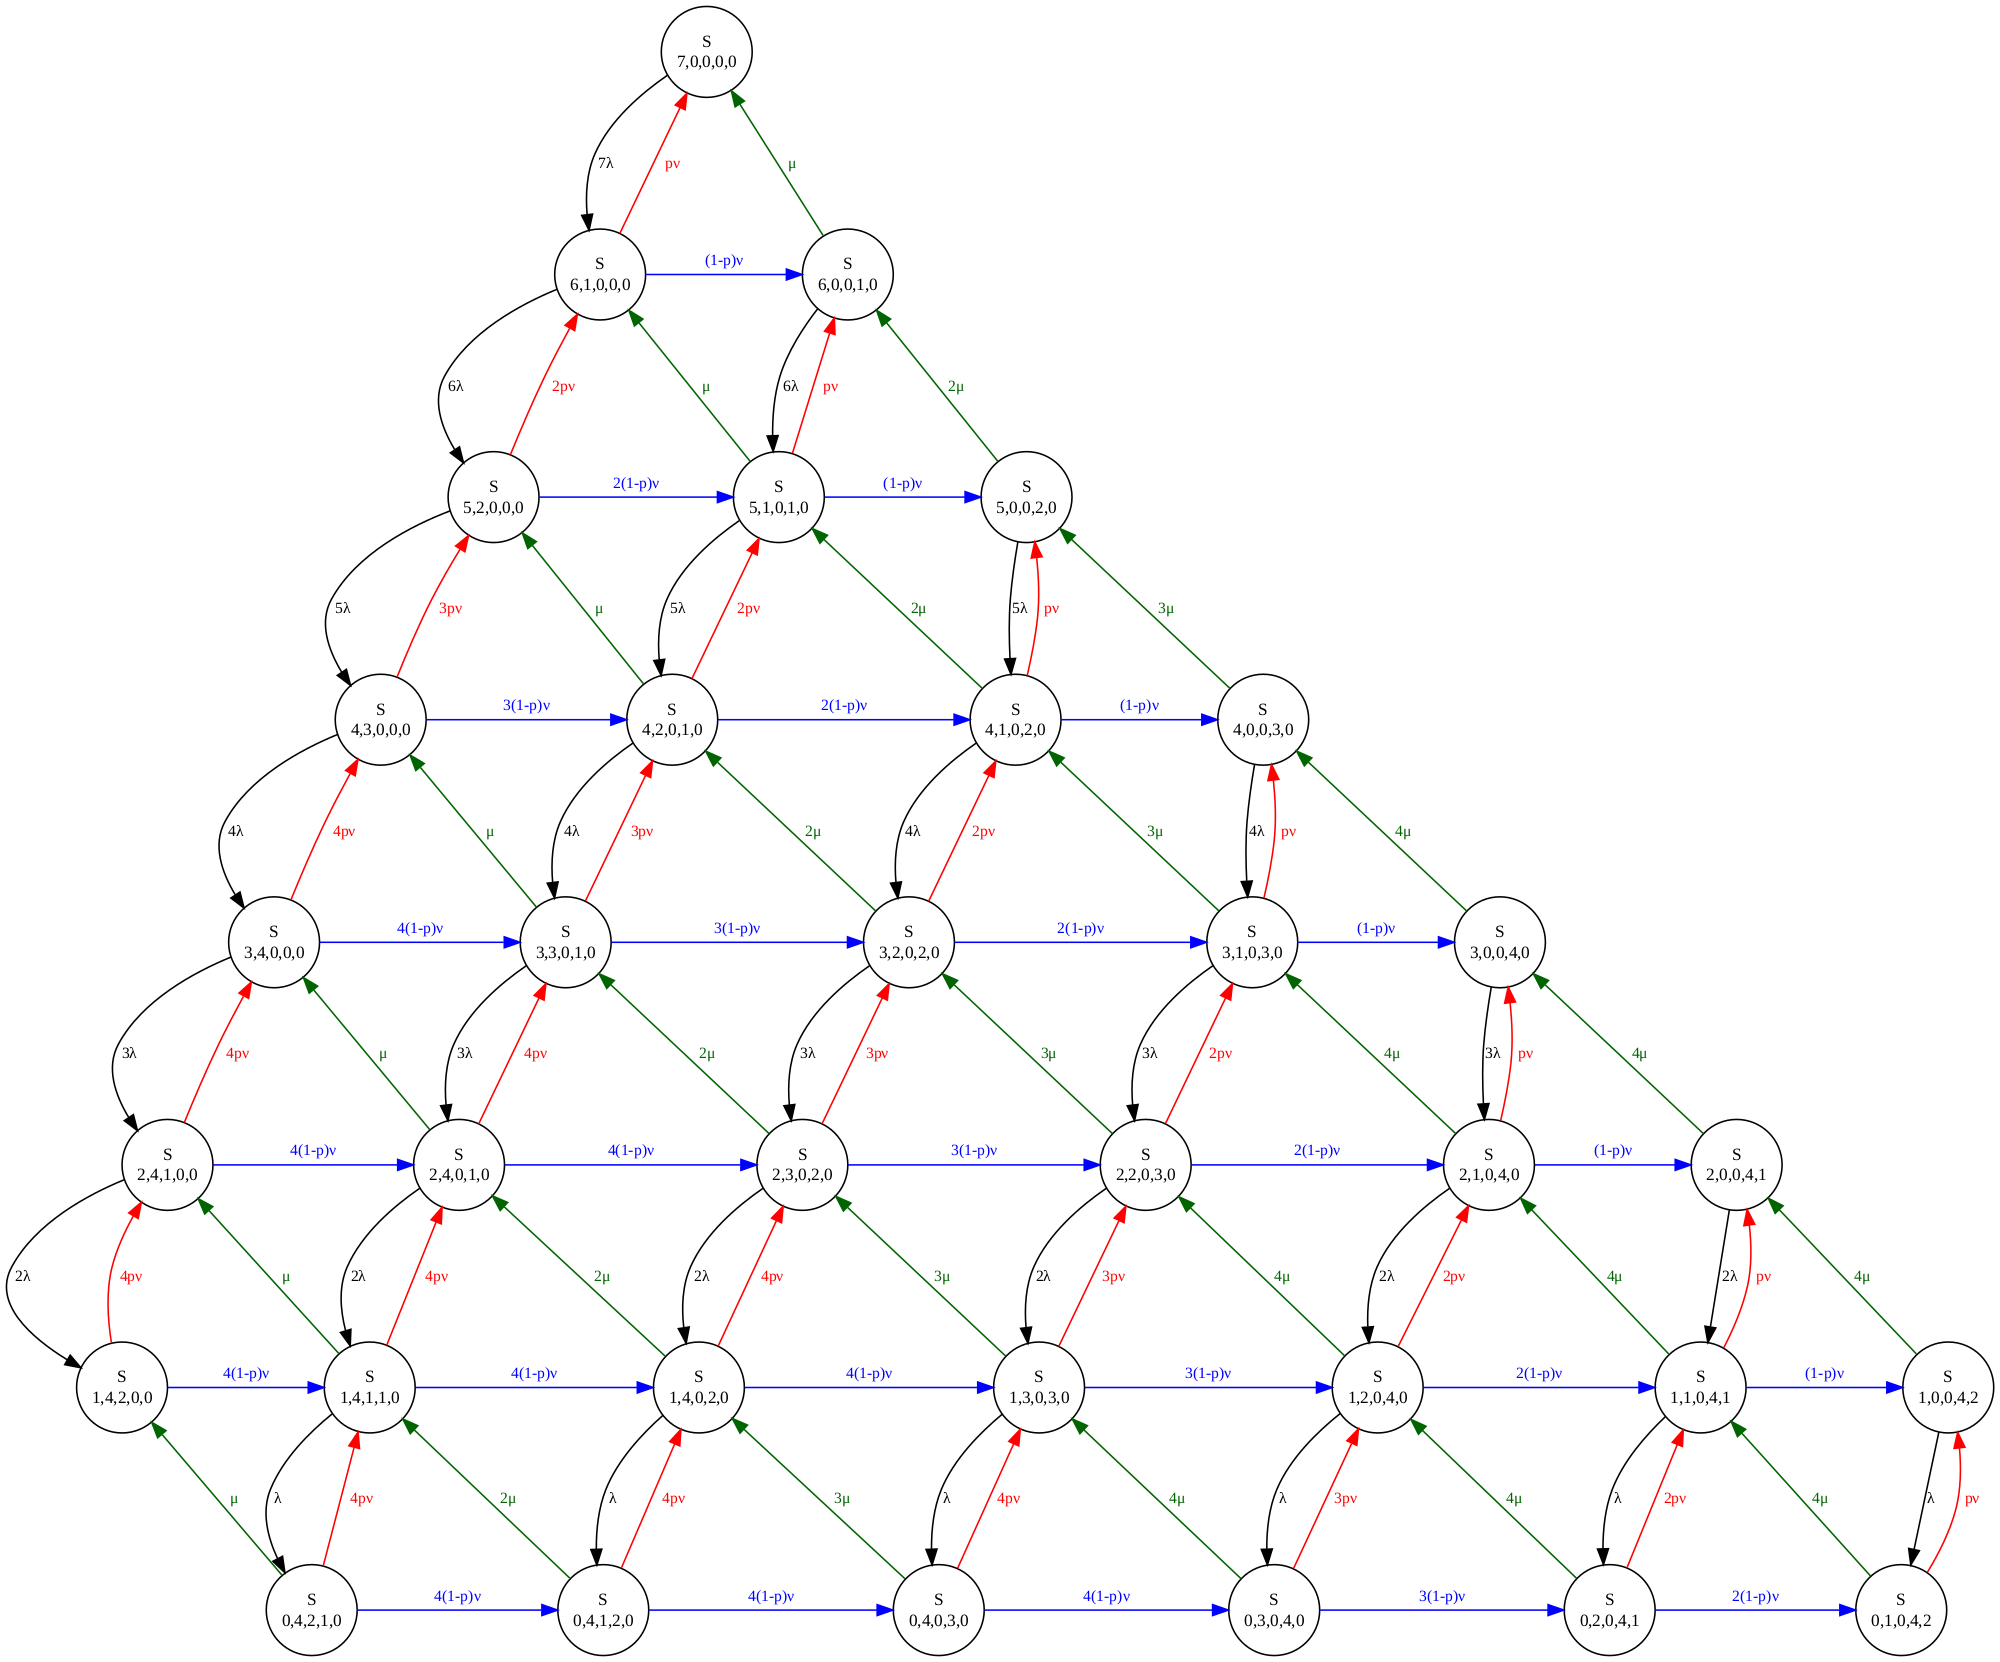

In [24]:
# Устанавливаем необходимые системные пакеты
system("apt-get update -qq")
system("apt-get install -y librsvg2-dev")

# Устанавливаем необходимые R-пакеты
if (!require("DiagrammeR")) install.packages("DiagrammeR")
if (!require("DiagrammeRsvg")) install.packages("DiagrammeRsvg")
if (!require("rsvg")) install.packages("rsvg")
if (!require("IRdisplay")) install.packages("IRdisplay")

library(DiagrammeR)
library(DiagrammeRsvg)
library(rsvg)
library(IRdisplay)

# --- Параметры варианта 19 ---
K <- 7; N <- 4; M <- 4; m1 <- 2; m2 <- 2

states <- list()
edges_list <- list() # This will be the final list of edges

# Функция добавления состояния
add_state <- function(k, n, q1, m, q2) {
  name <- paste0("S_", k, "_", n, "_", q1, "_", m, "_", q2)
  label <- paste0("S\n", k, ",", n, ",", q1, ",", m, ",", q2)
  if (!(name %in% names(states))) {
    states[[name]] <<- list(k=k, n=n, q1=q1, m=m, q2=q2, label=label, name=name)
    return(TRUE)
  }
  return(FALSE)
}

# Инициализация (все программисты пишут код)
queue <- list(c(K, 0, 0, 0, 0))
add_state(K, 0, 0, 0, 0)

# Генерация состояний
head <- 1
temp_edges_list <- list() # Temporary list to collect edges within the loop

while(head <= length(queue)) {
  curr <- queue[[head]]
  k <- curr[1]; n <- curr[2]; q1 <- curr[3]; m <- curr[4]; q2 <- curr[5]
  curr_name <- paste0("S_", k, "_", n, "_", q1, "_", m, "_", q2)
  head <- head + 1

  tot_AV <- n + q1
  tot_MS <- m + q2

  # 1. Программист написал код
  if (k > 0 && tot_AV < (N + m1)) {
    nn <- ifelse(n < N, n + 1, n)
    nq1 <- ifelse(n == N, q1 + 1, q1)
    if (add_state(k-1, nn, nq1, m, q2)) queue <- append(queue, list(c(k-1, nn, nq1, m, q2)))
    rate <- ifelse(k > 1, paste0(k, "λ"), "λ")
    temp_edges_list[[length(temp_edges_list)+1]] <- sprintf('"%s" -> "%s" [label="%s"];', curr_name, paste0("S_", k-1, "_", nn, "_", nq1, "_", m, "_", q2), rate)
  }

  # 2. Антивирус нашел вирус
  if (tot_AV > 0) {
    nn <- ifelse(q1 > 0, n, n - 1)
    nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    if (add_state(k+1, nn, nq1, m, q2)) queue <- append(queue, list(c(k+1, nn, nq1, m, q2)))
    rate <- ifelse(n > 1, paste0(n, "pν"), "pν")
    temp_edges_list[[length(temp_edges_list)+1]] <- sprintf('"%s" -> "%s" [label="%s", color="red", fontcolor="red"];', curr_name, paste0("S_", k+1, "_", nn, "_", nq1, "_", m, "_", q2), rate)
  }

  # 3. Антивирус пропустил код на сервер
  if (tot_AV > 0 && tot_MS < (M + m2)) {
    nn <- ifelse(q1 > 0, n, n - 1)
    nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    nm <- ifelse(m < M, m + 1, m)
    nq2 <- ifelse(m == M, q2 + 1, q2)
    if (add_state(k, nn, nq1, nm, nq2)) queue <- append(queue, list(c(k, nn, nq1, nm, nq2)))
    rate <- ifelse(n > 1, paste0(n, "(1-p)ν"), "(1-p)ν")
    temp_edges_list[[length(temp_edges_list)+1]] <- sprintf('"%s" -> "%s" [label="%s", color="blue", fontcolor="blue"];', curr_name, paste0("S_", k, "_", nn, "_", nq1, "_", nm, "_", nq2), rate)
  }

  # 4. Сервер выполнил программу
  if (tot_MS > 0) {
    nm <- ifelse(q2 > 0, m, m - 1)
    nq2 <- ifelse(q2 > 0, q2 - 1, 0)
    if (add_state(k+1, n, q1, nm, nq2)) queue <- append(queue, list(c(k+1, n, q1, nm, nq2)))
    rate <- ifelse(m > 1, paste0(m, "μ"), "μ")
    temp_edges_list[[length(temp_edges_list)+1]] <- sprintf('"%s" -> "%s" [label="%s", color="darkgreen", fontcolor="darkgreen"];', curr_name, paste0("S_", k+1, "_", n, "_", q1, "_", nm, "_", nq2), rate)
  }
}

edges_list <- temp_edges_list # Assign the collected edges to the global variable

# --- ГРУППИРОВКА ПО УРОВНЯМ ДЛЯ КРАСИВОГО ГРАФА ---
nodes_by_k <- list()
for (name in names(states)) {
  k_val <- as.character(states[[name]]$k)
  if (is.null(nodes_by_k[[k_val]])) nodes_by_k[[k_val]] <- c()
  nodes_by_k[[k_val]] <- c(nodes_by_k[[k_val]], sprintf('"%s" [label="%s"];', states[[name]]$name, states[[name]]$label))
}

graph_str <- "digraph G {\n  layout=dot;\n  rankdir=TB;\n  nodesep=0.7;\n  ranksep=1.0;\n  splines=true;\n  node [shape=circle, width=0.8, fixedsize=true, fontsize=11, style=filled, fillcolor=white];\n  edge [fontsize=10];\n"

# Принудительно выстраиваем состояния по уровням 'k'
for (k_val in sort(as.numeric(names(nodes_by_k)), decreasing = TRUE)) {
  graph_str <- paste0(graph_str, "  { rank=same;\n")
  graph_str <- paste0(graph_str, paste(nodes_by_k[[as.character(k_val)]], collapse="\n    "), "\n")
  graph_str <- paste0(graph_str, "  }\n")
}

graph_str <- paste0(graph_str, paste(edges_list, collapse="\n  "), "\n}")

# --- Экспорт и отображение ---
g <- grViz(graph_str)
svg_code <- export_svg(g)
writeLines(svg_code, "graph.svg")
rsvg_png(charToRaw(svg_code), "graph.png", width = 2000)

cat("Успешно сгенерировано состояний:", length(states), "\n")
display_png(file="graph.png")

### Уравнения Колмогорова

### Уравнения Колмогорова для вероятностей состояний

В связи с большой размерностью системы (34 возможных состояния для $K=7$), полная запись системы дифференциальных уравнений Колмогорова является громоздкой. Запишем общее правило формирования уравнений: производная вероятности нахождения системы в $i$-ом состоянии равна сумме потоков вероятностей, переводящих систему в это состояние (входящие потоки), минус сумма потоков вероятностей, выводящих систему из этого состояния (исходящие потоки).

Для примера составим уравнения Колмогорова для первых нескольких (верхних) состояний графа:

**1. Для состояния $S_{7,0,0,0,0}$ (все 7 программистов пишут код):**
В это состояние система может перейти, если антивирус найдет вирус в $S_{6,1,0,0,0}$ (интенсивность $p\nu$), либо если сервер закончит обработку программы из $S_{6,0,0,1,0}$ (интенсивность $\mu$). Выходит система из этого состояния, когда любой из 7 программистов дописывает код (интенсивность $7\lambda$).
$$\frac{dP_{70000}(t)}{dt} = - 7\lambda P_{70000}(t) + p\nu P_{61000}(t) + \mu P_{60010}(t)$$

**2. Для состояния $S_{6,1,0,0,0}$ (6 пишут, 1 проверяется на вирусы):**
$$\frac{dP_{61000}(t)}{dt} = 7\lambda P_{70000}(t) + 2p\nu P_{52000}(t) + \mu P_{51010}(t) - (6\lambda + p\nu + (1-p)\nu) P_{61000}(t)$$
*Примечание: $(p\nu + (1-p)\nu) = \nu$, так как антивирус в любом случае завершает проверку.*

**3. Для состояния $S_{6,0,0,1,0}$ (6 пишут, 1 исполняется на сервере):**
$$\frac{dP_{60010}(t)}{dt} = (1-p)\nu P_{61000}(t) + p\nu P_{51010}(t) + 2\mu P_{50020}(t) - (6\lambda + \mu) P_{60010}(t)$$

И так далее для всех 34 состояний.

### Финальные (стационарные) вероятности

Для нахождения финальных (стационарных) вероятностей, при $t \to \infty$, производные приравниваются к нулю: $\frac{dP_i(t)}{dt} = 0$.

Система алгебраических уравнений для стационарных вероятностей имеет вид:
$$ P \cdot Q = 0 $$
где $P = [P_1, P_2, ..., P_{34}]$ — вектор стационарных вероятностей, а $Q$ — матрица интенсивностей переходов (инфинитезимальная матрица).

Для получения однозначного решения одно из уравнений системы заменяется нормировочным условием:
$$ \sum_{i=1}^{34} P_i = 1 $$

.

**Уравнение нормировки**

Сумма вероятностей нахождения системы во всех 34 возможных состояниях всегда равна единице. Математически это записывается через сумму по всему пространству состояний $S$:

$$ \sum_{(k,n,q_1,m,q_2) \in S} P_{k,n,q_1,m,q_2} = 1 $$

В развернутом виде:
$$ P_{70000} + P_{61000} + P_{60010} + P_{52000} + \dots + P_{00142} = 1 $$

Для нахождения финальных (стационарных) вероятностей при $t \to \infty$ положим левую часть дифференциальных уравнений Колмогорова равной нулю (так как система приходит в равновесие, вероятности состояний перестают меняться, и их производные равны нулю).

В связи с большой размерностью системы (34 состояния), выпишем систему алгебраических уравнений для первых нескольких узлов графа:

$$
\begin{cases}
0 = - 7\lambda P_{70000} + p\nu P_{61000} + \mu P_{60010} \\[6pt]
0 = 7\lambda P_{70000} + 2p\nu P_{52000} + \mu P_{51010} - (6\lambda + \nu) P_{61000} \\[6pt]
0 = (1-p)\nu P_{61000} + p\nu P_{51010} + 2\mu P_{50020} - (6\lambda + \mu) P_{60010} \\[6pt]
0 = 6\lambda P_{61000} + 3p\nu P_{43000} + \mu P_{42010} - (5\lambda + 2\nu) P_{52000} \\[6pt]
\dots \\[6pt]
\text{(и так далее для всех 34 состояний)}
\end{cases}
$$

*(Примечание: для компактности записи учтено, что $p\nu + (1-p)\nu = \nu$)*

Полная система состоит из 34 линейных алгебраических уравнений. Решать её аналитически (вручную методом подстановки) нецелесообразно. Для нахождения численных значений стационарных вероятностей мы сформируем инфинитезимальную матрицу переходов программно и решим СЛАУ матричным методом. Одно из уравнений системы при решении будет заменено нормировочным условием $\sum P_i = 1$.

### Основные характеристики СМО

#### Теоретически по уравнениям Колмогорова

In [ ]:
install.packages("rim")
library(rim)

Устанавливаю пакет в ‘/opt/homebrew/lib/R/4.5/site-library’
(потому что ‘lib’ не определено)





                 _____                        
                |  ___| __ ___  ___           
                | |_ | '__/ _ \/ _ \          
                |  _|| | |  __/  __/          
      ____      |_|  |_|  \___|\___|          
     |  _ \ __ _| | ___  ___| |_(_)_ __   ___ 
     | |_) / _` | |/ _ \/ __| __| | '_ \ / _ \
     |  __/ (_| | |  __/\__ \ |_| | | | |  __/
     |_|   \__,_|_|\___||___/\__|_|_| |_|\___|




Maxima successfully registered as knitr engine!



In [ ]:
maxima.isInstalled()

[1] TRUE

In [1]:
# --- Исходные данные для Варианта 19 ---
K <- 7; N <- 4; M <- 4; m1 <- 2; m2 <- 2
lambda <- 0.6054255
mu <- 0.08142403
nu <- 0.4713214
p <- 0.07394703

# 1. Генерируем список состояний
states <- list()
add_state <- function(k, n, q1, m, q2) {
  name <- paste0("P_", k, "_", n, "_", q1, "_", m, "_", q2)
  if (!(name %in% names(states))) {
    states[[name]] <<- list(k=k, n=n, q1=q1, m=m, q2=q2, name=name)
    return(TRUE)
  }
  return(FALSE)
}

queue <- list(c(K, 0, 0, 0, 0))
add_state(K, 0, 0, 0, 0)
head <- 1
while(head <= length(queue)) {
  curr <- queue[[head]]
  head <- head + 1
  k <- curr[1]; n <- curr[2]; q1 <- curr[3]; m <- curr[4]; q2 <- curr[5]

  tot_AV <- n + q1
  tot_MS <- m + q2

  if (k > 0 && tot_AV < (N + m1)) {
    nn <- ifelse(n < N, n + 1, n); nq1 <- ifelse(n == N, q1 + 1, q1)
    if (add_state(k-1, nn, nq1, m, q2)) queue <- append(queue, list(c(k-1, nn, nq1, m, q2)))
  }
  if (tot_AV > 0) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    if (add_state(k+1, nn, nq1, m, q2)) queue <- append(queue, list(c(k+1, nn, nq1, m, q2)))
  }
  if (tot_AV > 0 && tot_MS < (M + m2)) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    nm <- ifelse(m < M, m + 1, m); nq2 <- ifelse(m == M, q2 + 1, q2)
    if (add_state(k, nn, nq1, nm, nq2)) queue <- append(queue, list(c(k, nn, nq1, nm, nq2)))
  }
  if (tot_MS > 0) {
    nm <- ifelse(q2 > 0, m, m - 1); nq2 <- ifelse(q2 > 0, q2 - 1, 0)
    if (add_state(k+1, n, q1, nm, nq2)) queue <- append(queue, list(c(k+1, n, q1, nm, nq2)))
  }
}

state_names <- names(states)
num_states <- length(state_names)

# 2. Создаем и заполняем матрицу переходов Q (размер 34x34)
Q <- matrix(0, nrow=num_states, ncol=num_states)
rownames(Q) <- state_names
colnames(Q) <- state_names

get_idx <- function(name) which(state_names == name)

for (name in state_names) {
  curr <- states[[name]]
  k <- curr$k; n <- curr$n; q1 <- curr$q1; m <- curr$m; q2 <- curr$q2
  tot_AV <- n + q1
  tot_MS <- m + q2
  i <- get_idx(name)

  if (k > 0 && tot_AV < (N + m1)) {
    nn <- ifelse(n < N, n + 1, n); nq1 <- ifelse(n == N, q1 + 1, q1)
    next_name <- paste0("P_", k-1, "_", nn, "_", nq1, "_", m, "_", q2)
    Q[i, get_idx(next_name)] <- k * lambda
  }
  if (tot_AV > 0) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    next_name <- paste0("P_", k+1, "_", nn, "_", nq1, "_", m, "_", q2)
    Q[i, get_idx(next_name)] <- n * p * nu
  }
  if (tot_AV > 0 && tot_MS < (M + m2)) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    nm <- ifelse(m < M, m + 1, m); nq2 <- ifelse(m == M, q2 + 1, q2)
    next_name <- paste0("P_", k, "_", nn, "_", nq1, "_", nm, "_", nq2)
    Q[i, get_idx(next_name)] <- n * (1-p) * nu
  }
  if (tot_MS > 0) {
    nm <- ifelse(q2 > 0, m, m - 1); nq2 <- ifelse(q2 > 0, q2 - 1, 0)
    next_name <- paste0("P_", k+1, "_", n, "_", q1, "_", nm, "_", nq2)
    Q[i, get_idx(next_name)] <- m * mu
  }
}

for(i in 1:num_states) Q[i,i] <- -sum(Q[i, -i])

# 3. Решаем систему
A <- t(Q)
b <- rep(0, num_states)
A[num_states, ] <- 1
b[num_states] <- 1

probabilities <- solve(A, b)

# Сохраняем вероятности в удобный список для следующих расчетов
P <- list()
for (i in 1:num_states) {
  P[[state_names[i]]] <- probabilities[i]
}

cat("Система из", num_states, "уравнений успешно решена!\n")
cat("Сумма вероятностей:", sum(probabilities), "(если 1, то всё верно)\n")

[1] TRUE

Система из 34 уравнений успешно решена!
Сумма вероятностей: 1 (если 1, то всё верно)


In [3]:
# --- Расчет теоретических характеристик эффективности СМО ---

# 1. Среднее число работающих программистов (заявок, которые еще не поступили в СМО)
K_avg <- 0
for (name in names(states)) {
  K_avg <- K_avg + states[[name]]$k * P[[name]]
}

# 2. Среднее число заявок внутри системы (в очередях и на обслуживании)
# Так как система замкнутая (всего K программистов), то:
L_sys <- K - K_avg

# 3. Абсолютная пропускная способность (A)
# Это среднее число заявок, успешно выполненных серверами в единицу времени.
# Заявка покидает СМО и возвращается программисту, когда основной сервер заканчивает работу.
# Интенсивность этого потока в каждом состоянии равна (m * mu)
A <- 0
for (name in names(states)) {
  A <- A + states[[name]]$m * mu * P[[name]]
}

# 4. Среднее время пребывания заявки в системе (W)
# Применяем закон Литтла для замкнутых систем: L_sys = A * W => W = L_sys / A
W <- L_sys / A

# Красивый вывод результатов
cat("--- ТЕОРЕТИЧЕСКИЕ ХАРАКТЕРИСТИКИ ЭФФЕКТИВНОСТИ СМО ---\n")
cat("1. Среднее число заявок в системе (L_sys):", round(L_sys, 4), "\n")
cat("2. Абсолютная пропускная способность (A):", round(A, 4), "заявок в ед. времени\n")
cat("3. Среднее время пребывания заявки в системе (W):", round(W, 4), "ед. времени\n")

--- ТЕОРЕТИЧЕСКИЕ ХАРАКТЕРИСТИКИ ЭФФЕКТИВНОСТИ СМО ---
1. Среднее число заявок в системе (L_sys): 6.4046 
2. Абсолютная пропускная способность (A): 0.3205 заявок в ед. времени
3. Среднее время пребывания заявки в системе (W): 19.9826 ед. времени


### Метод укрупнения состояний

[1] TRUE

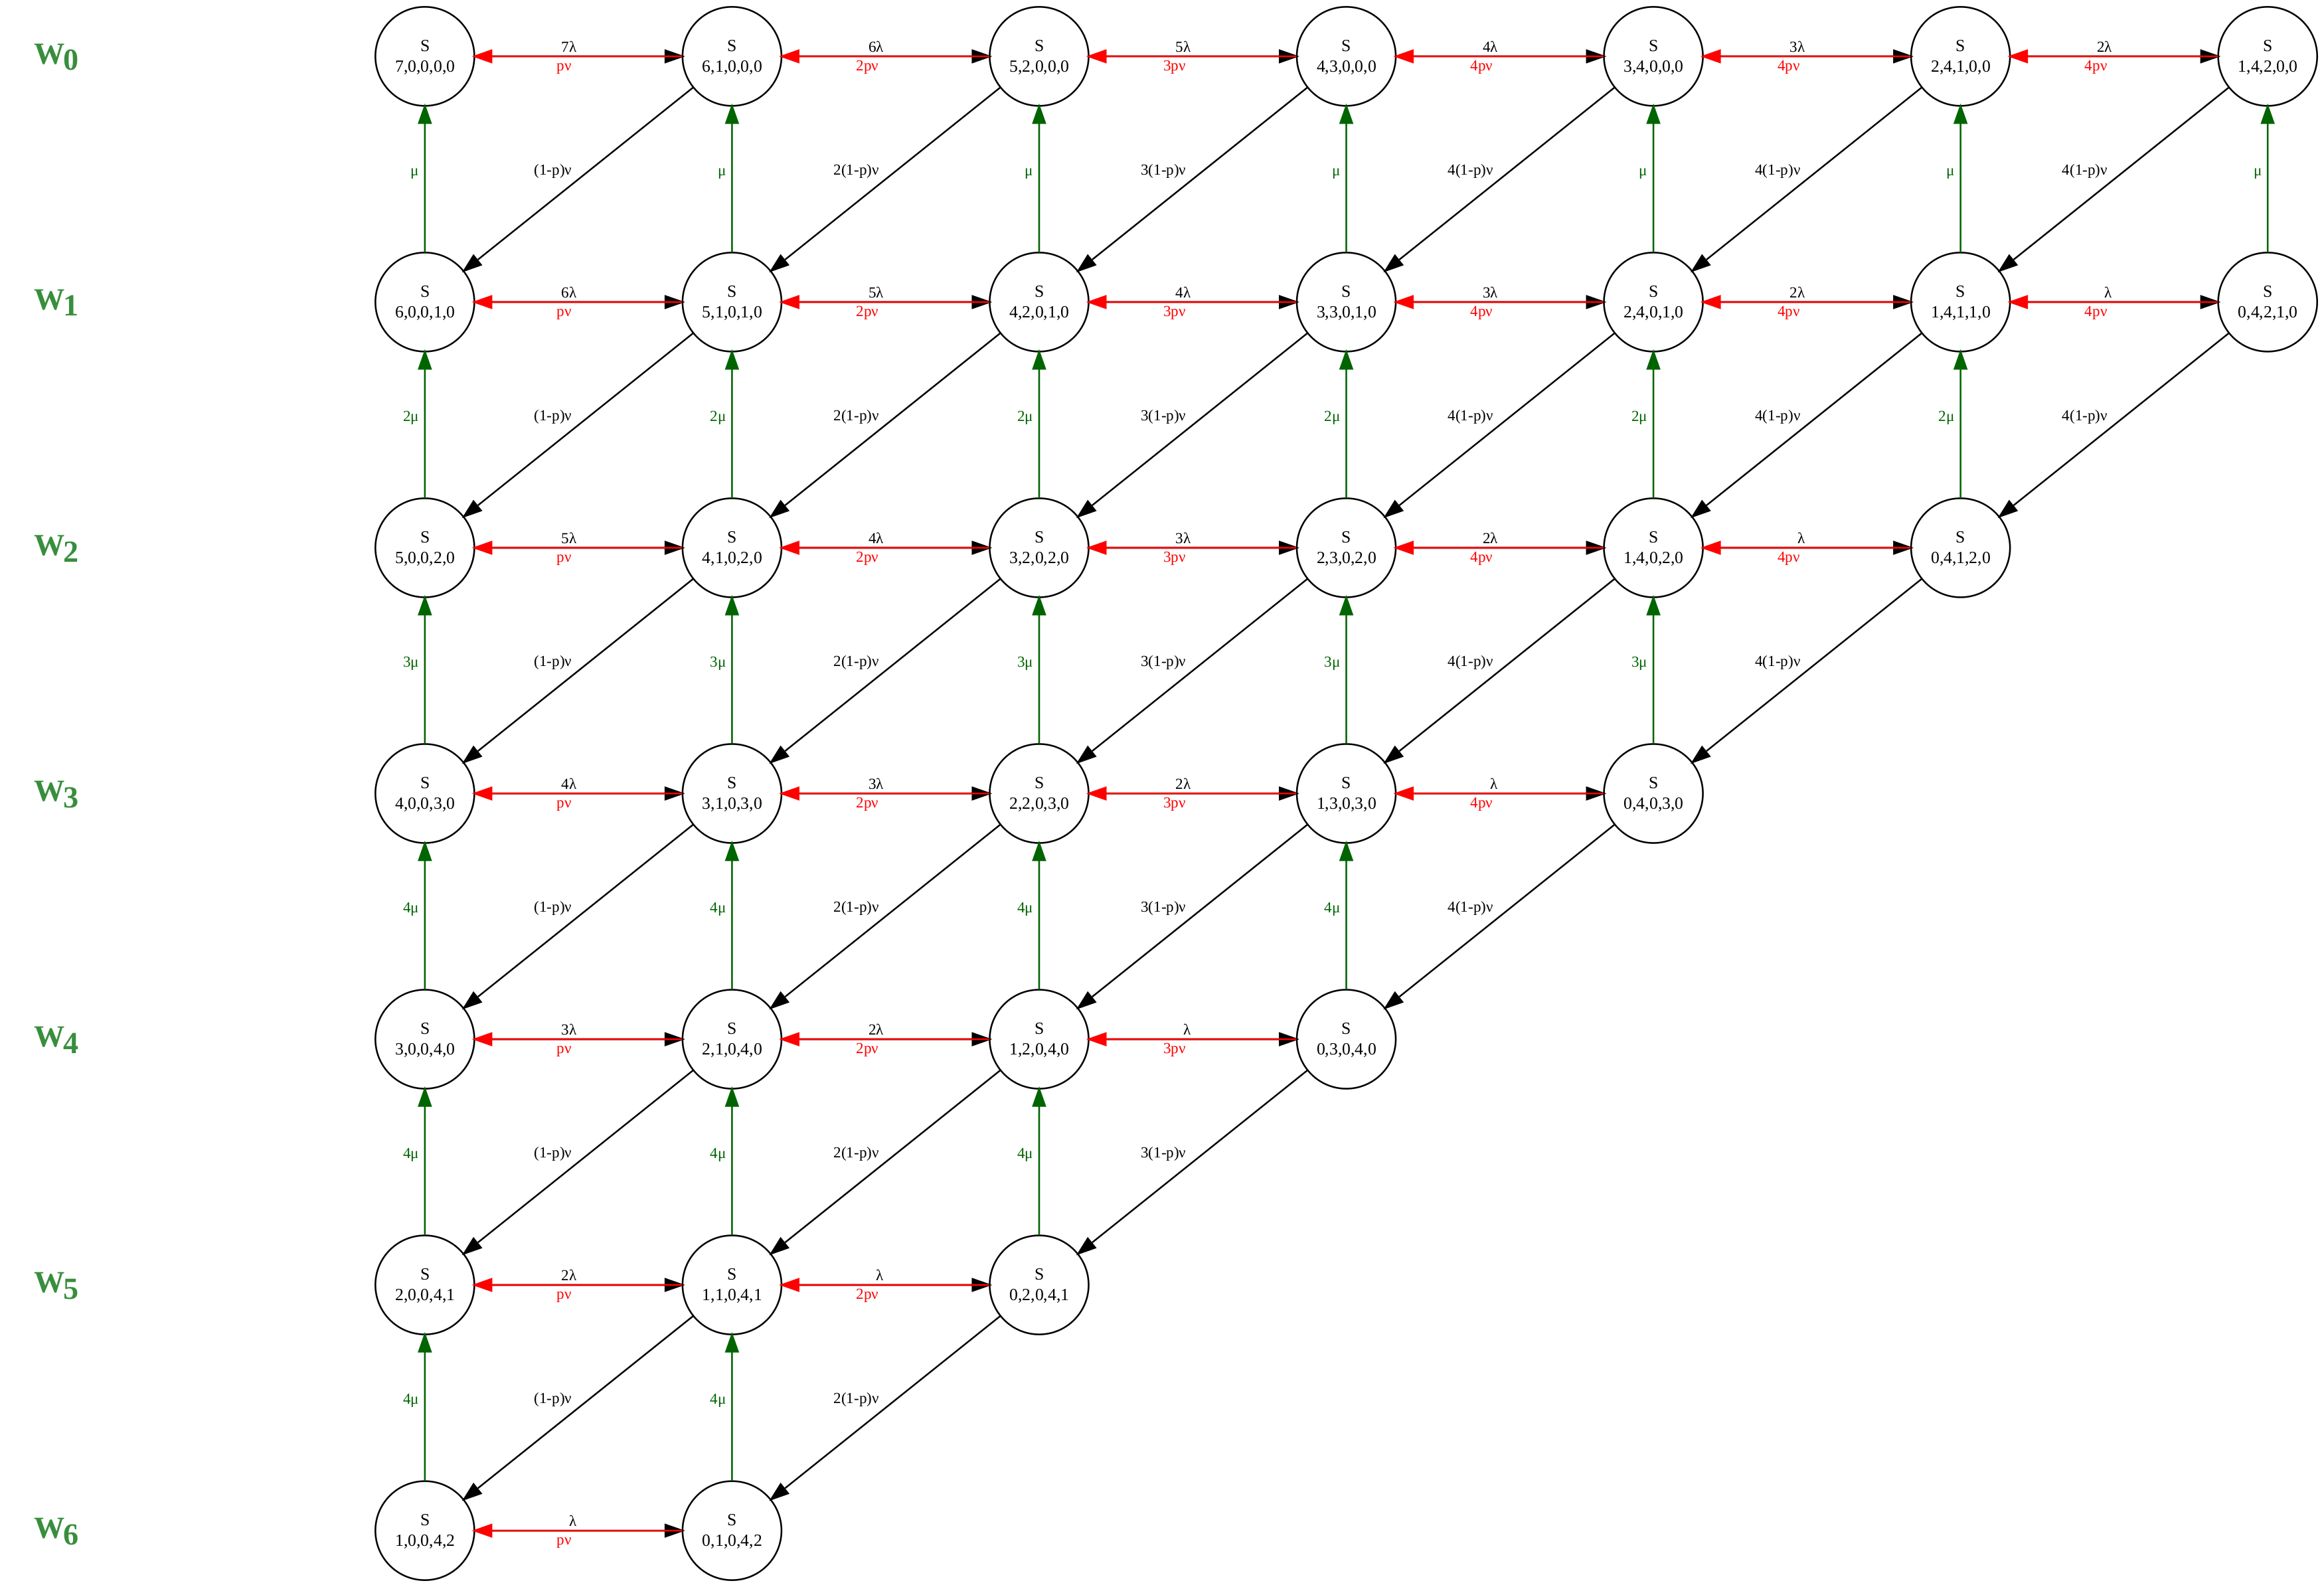



=============== for MARKDOWN output this  ===============
### Горизонтальное укрупнение

$$W_0 = \{ S_{70000}, S_{61000}, S_{52000}, S_{43000}, S_{34000}, S_{24100}, S_{14200} \}$$

$$W_1 = \{ S_{60010}, S_{51010}, S_{42010}, S_{33010}, S_{24010}, S_{14110}, S_{04210} \}$$

$$W_2 = \{ S_{50020}, S_{41020}, S_{32020}, S_{23020}, S_{14020}, S_{04120} \}$$

$$W_3 = \{ S_{40030}, S_{31030}, S_{22030}, S_{13030}, S_{04030} \}$$

$$W_4 = \{ S_{30040}, S_{21040}, S_{12040}, S_{03040} \}$$

$$W_5 = \{ S_{20041}, S_{11041}, S_{02041} \}$$

$$W_6 = \{ S_{10042}, S_{01042} \}$$



In [13]:
system("apt-get update -qq")
system("apt-get install -y librsvg2-dev")

# Устанавливаем пакеты, если вдруг они пропали
if (!require("DiagrammeR")) install.packages("DiagrammeR")
if (!require("DiagrammeRsvg")) install.packages("DiagrammeRsvg")
if (!require("rsvg")) install.packages("rsvg")
if (!require("IRdisplay")) install.packages("IRdisplay")

library(DiagrammeR)
library(DiagrammeRsvg)
library(rsvg)
library(IRdisplay)

# Исходные данные варианта 19
K <- 7; N <- 4; M <- 4; m1 <- 2; m2 <- 2

states <- list()
edges_list_temp <- list() # Use a temporary list for edge collection

add_state <- function(k, n, q1, m, q2) {
  name <- paste0("S_", k, "_", n, "_", q1, "_", m, "_", q2)
  label <- paste0("S\n", k, ",", n, ",", q1, ",", m, ",", q2)
  if (!(name %in% names(states))) {
    # Рассчитываем координаты сетки
    # X зависит от загрузки антивируса, Y зависит от загрузки серверов
    v <- n + q1
    w <- m + q2
    x_pos <- v * 2.5
    y_pos <- -w * 2.0

    states[[name]] <<- list(k=k, n=n, q1=q1, m=m, q2=q2, label=label, name=name, v=v, w=w, x=x_pos, y=y_pos)
    return(TRUE)
  }
  return(FALSE)
}

queue <- list(c(K, 0, 0, 0, 0))
add_state(K, 0, 0, 0, 0)
head <- 1

while(head <= length(queue)) {
  curr <- queue[[head]]; head <- head + 1
  k <- curr[1]; n <- curr[2]; q1 <- curr[3]; m <- curr[4]; q2 <- curr[5]
  curr_name <- paste0("S_", k, "_", n, "_", q1, "_", m, "_", q2)
  tot_AV <- n + q1; tot_MS <- m + q2

  if (k > 0 && tot_AV < (N + m1)) {
    nn <- ifelse(n < N, n + 1, n); nq1 <- ifelse(n == N, q1 + 1, q1)
    if (add_state(k-1, nn, nq1, m, q2)) queue <- append(queue, list(c(k-1, nn, nq1, m, q2)))
    rate <- ifelse(k > 1, paste0(k, "λ"), "λ")
    edges_list_temp[[length(edges_list_temp)+1]] <- sprintf('"%s" -> "%s" [label="%s"];', curr_name, paste0("S_", k-1, "_", nn, "_", nq1, "_", m, "_", q2), rate)
  }
  if (tot_AV > 0) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    if (add_state(k+1, nn, nq1, m, q2)) queue <- append(queue, list(c(k+1, nn, nq1, m, q2)))
    rate <- ifelse(n > 1, paste0(n, "pν"), "pν")
    # Добавляем искривление для обратной связи, чтобы стрелка не шла сквозь другие узлы
    edges_list_temp[[length(edges_list_temp)+1]] <- sprintf('"%s" -> "%s" [label="%s", color="red", fontcolor="red"];', curr_name, paste0("S_", k+1, "_", nn, "_", nq1, "_", m, "_", q2), rate)
  }
  if (tot_AV > 0 && tot_MS < (M + m2)) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    nm <- ifelse(m < M, m + 1, m); nq2 <- ifelse(m == M, q2 + 1, q2)
    if (add_state(k, nn, nq1, nm, nq2)) queue <- append(queue, list(c(k, nn, nq1, nm, nq2)))
    rate <- ifelse(n > 1, paste0(n, "(1-p)ν"), "(1-p)ν")
    edges_list_temp[[length(edges_list_temp)+1]] <- sprintf('"%s" -> "%s" [label="%s"];', curr_name, paste0("S_", k, "_", nn, "_", nq1, "_", nm, "_", nq2), rate)
  }
  if (tot_MS > 0) {
    nm <- ifelse(q2 > 0, m, m - 1); nq2 <- ifelse(q2 > 0, q2 - 1, 0)
    if (add_state(k+1, n, q1, nm, nq2)) queue <- append(queue, list(c(k+1, n, q1, nm, nq2)))
    rate <- ifelse(m > 1, paste0(m, "μ"), "μ")
    # Зеленая стрелка для успешного выполнения
    edges_list_temp[[length(edges_list_temp)+1]] <- sprintf('"%s" -> "%s" [label="%s", color="darkgreen", fontcolor="darkgreen"];', curr_name, paste0("S_", k+1, "_", n, "_", q1, "_", nm, "_", nq2), rate)
  }
}

edges_list <- edges_list_temp # Assign the collected edges to the main variable

# --- ФОРМИРОВАНИЕ ГРАФА ---
# Используем neato и сплайны для аккуратного огибания узлов
graph_str <- "digraph G {\n  layout=neato;\n  splines=true;\n  overlap=false;\n  node [shape=circle, width=0.8, fixedsize=true, fontsize=10, style=filled, fillcolor=white];\n  edge [fontsize=9];\n"

# 1. Рисуем узлы по заданным координатам pos="x,y!" (знак ! запрещает программе их двигать)
for (name in names(states)) {
  s <- states[[name]]
  graph_str <- paste0(graph_str, sprintf('  "%s" [label="%s", pos="%f,%f!"];\n', name, s$label, s$x, s$y))
}

# 2. Рисуем левые подписи W_0, W_1 ... для визуализации горизонтального укрупнения
clusters_list <- list()
for (w in 0:(M+m2)) {
  nodes_in_w <- names(states)[sapply(states, function(s) s$w == w)]
  if (length(nodes_in_w) > 0) {
    clusters_list[[as.character(w)]] <- nodes_in_w
    # Создаем прозрачный узел с текстом W слева от графа (X = -3)
    graph_str <- paste0(graph_str, sprintf('  "W_label_%d" [shape=none, label=<<font color="#388E3C" point-size="18"><b>W<SUB>%d</SUB></b></font>>, pos="-3.0,%f!"];\n', w, w, -w*2.0))
  }
}

# 3. Добавляем связи
graph_str <- paste0(graph_str, paste(edges_list, collapse="\n  "), "\n}")

g <- grViz(graph_str)
svg_code <- export_svg(g)
rsvg_png(charToRaw(svg_code), "graph_grid.png", width = 3500)

display_png(file="graph_grid.png")

# --- ТЕКСТ ДЛЯ ОТЧЕТА ---
cat("\n\n=============== for MARKDOWN output this  ===============\n")
cat("### Горизонтальное укрупнение\n\n")

for (w in names(clusters_list)) {
  nodes <- clusters_list[[w]]
  formatted_nodes <- sapply(nodes, function(x) {
    parts <- strsplit(x, "_")[[1]]
    paste0("S_{", paste(parts[2:6], collapse=""), "}")
  })
  cat(paste0("$$W_", w, " = \\{ ", paste(formatted_nodes, collapse=", "), " \\}$$\n\n"))
}
cat("=======================================================================\n")

### Горизонтальное укрупнение

$$W_0 = \{ S_{70000}, S_{61000}, S_{52000}, S_{43000}, S_{34000}, S_{24100}, S_{14200} \}$$

$$W_1 = \{ S_{60010}, S_{51010}, S_{42010}, S_{33010}, S_{24010}, S_{14110}, S_{04210} \}$$

$$W_2 = \{ S_{50020}, S_{41020}, S_{32020}, S_{23020}, S_{14020}, S_{04120} \}$$

$$W_3 = \{ S_{40030}, S_{31030}, S_{22030}, S_{13030}, S_{04030} \}$$

$$W_4 = \{ S_{30040}, S_{21040}, S_{12040}, S_{03040} \}$$

$$W_5 = \{ S_{20041}, S_{11041}, S_{02041} \}$$

$$W_6 = \{ S_{10042}, S_{01042} \}$$

3. Граф макро-состояний W:


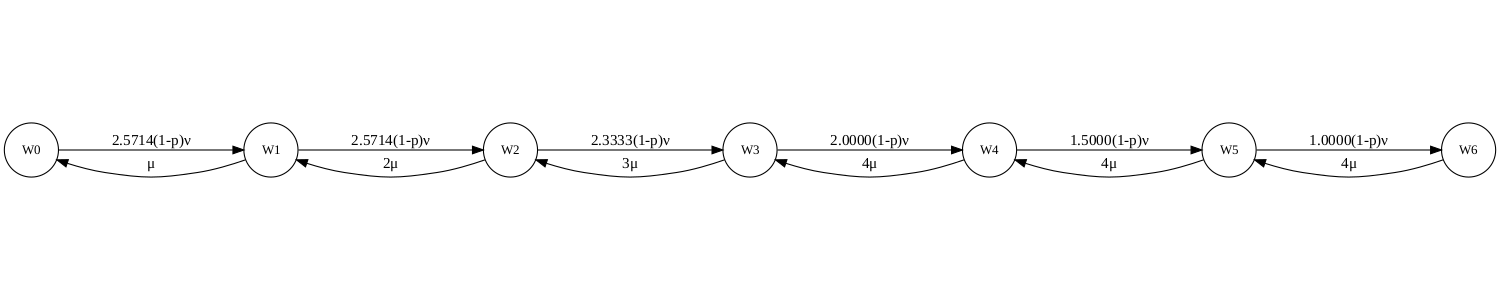

In [50]:
# 3. Рисуем граф макро-состояний
cat("3. Граф макро-состояний W:\n")
# Изменили rankdir на LR (Left-to-Right) и добавили ranksep для расстояния между узлами
macro_graph <- "digraph MacroG {\n  rankdir=LR;\n  ranksep=1.2;\n  node [shape=circle, width=0.7, fixedsize=true, fontsize=12];\n"

for (w_val in 0:(M+m2)) {
  macro_graph <- paste0(macro_graph, sprintf('  "W%d" [label="W%d"];\n', w_val, w_val))
}
for (w_val in 0:(M+m2-1)) {
  # Переход слева направо (поступление на сервер)
  rate_down <- sprintf("%.4f(1-p)ν", as.numeric(unname(z[w_val+1])))
  macro_graph <- paste0(macro_graph, sprintf('  "W%d" -> "W%d" [label="%s"];\n', w_val, w_val+1, rate_down))

  # Переход справа налево (обслуживание сервером)
  m_val <- min(w_val+1, M)
  rate_up <- ifelse(m_val==1, "μ", sprintf("%dμ", m_val))
  macro_graph <- paste0(macro_graph, sprintf('  "W%d" -> "W%d" [label="%s"];\n', w_val+1, w_val, rate_up))
}
macro_graph <- paste0(macro_graph, "}")

g_macro <- grViz(macro_graph)
# ВАЖНО: Увеличили width до 1200, так как граф из 7 кружочков будет длинным
rsvg_png(charToRaw(export_svg(g_macro)), file="macro_graph.png", width=1500, height=300)
display_png(file="macro_graph.png")

#### Вертикальное укрупнение

[1] TRUE

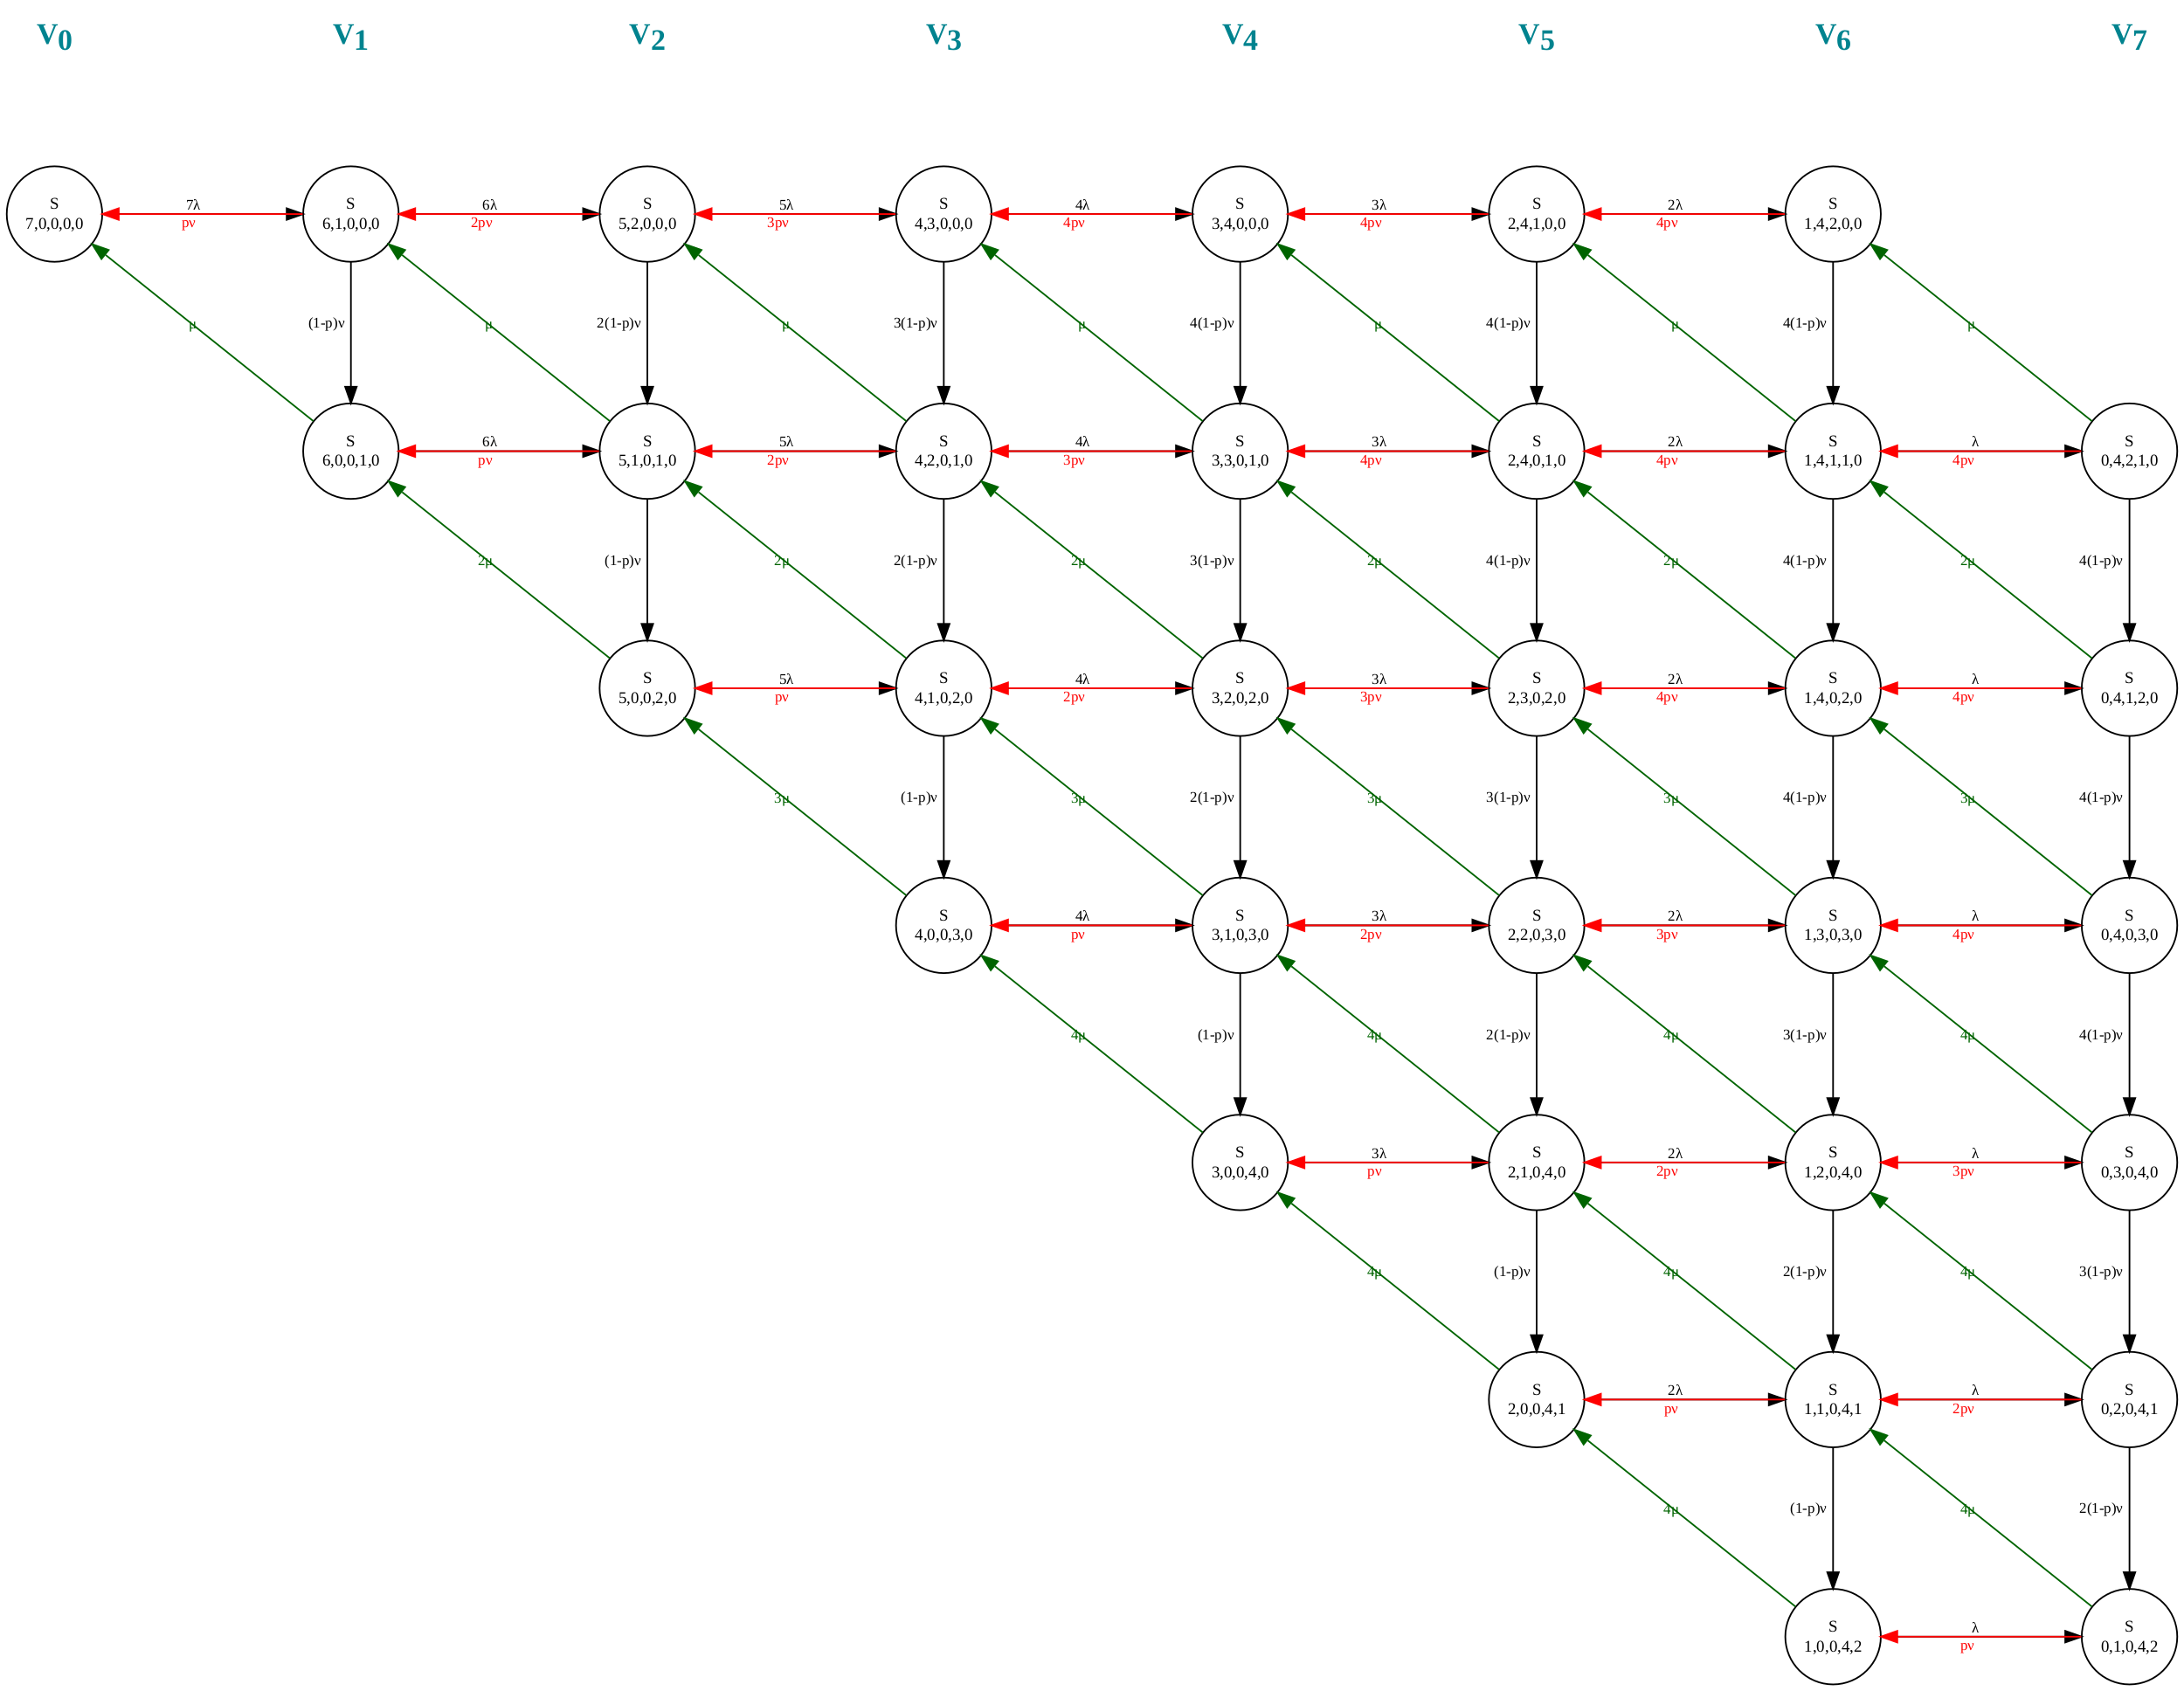


--- Точные вероятности укрупненных состояний (V_0 ... V_7) ---
P_V_0 = 0.000000
P_V_1 = 0.000006
P_V_2 = 0.000159
P_V_3 = 0.002197
P_V_4 = 0.018239
P_V_5 = 0.098290
P_V_6 = 0.334485
P_V_7 = 0.546623
Сумма = 1.000000


=============== for MARKDOWN ===============
### Вертикальное укрупнение

$$
V_0 = { S_{70000} }
$$

$$
V_1 = { S_{61000}, S_{60010} }
$$

$$
V_2 = { S_{52000}, S_{51010}, S_{50020} }
$$

$$
V_3 = { S_{43000}, S_{42010}, S_{41020}, S_{40030} }
$$

$$
V_4 = { S_{34000}, S_{33010}, S_{32020}, S_{31030}, S_{30040} }
$$

$$
V_5 = { S_{24100}, S_{24010}, S_{23020}, S_{22030}, S_{21040}, S_{20041} }
$$

$$
V_6 = { S_{14200}, S_{14110}, S_{14020}, S_{13030}, S_{12040}, S_{11041}, S_{10042} }
$$

$$
V_7 = { S_{04210}, S_{04120}, S_{04030}, S_{03040}, S_{02041}, S_{01042} }
$$



In [43]:
# --- ВЕРТИКАЛЬНОЕ УКРУПНЕНИЕ: ГРАФ И ТОЧНЫЕ ВЕРОЯТНОСТИ ---

library(DiagrammeR)
library(DiagrammeRsvg)
library(rsvg)
library(IRdisplay)

# Исходные данные
K <- 7; N <- 4; M <- 4; m1 <- 2; m2 <- 2

states <- list()
edges_list <- list()

add_state <- function(k, n, q1, m, q2) {
  name <- paste0("S_", k, "_", n, "_", q1, "_", m, "_", q2)
  label <- paste0("S\n", k, ",", n, ",", q1, ",", m, ",", q2)
  if (!(name %in% names(states))) {
    # Для ИДЕАЛЬНОЙ сетки вертикального укрупнения:
    # X = сколько всего заявок в системе (K - k)
    # Y = сколько заявок на сервере (m + q2)
    v_sys <- K - k
    w_serv <- m + q2

    x_pos <- v_sys * 2.5
    y_pos <- -w_serv * 2.0

    states[[name]] <<- list(k=k, n=n, q1=q1, m=m, q2=q2, label=label, name=name, v_sys=v_sys, x=x_pos, y=y_pos)
    return(TRUE)
  }
  return(FALSE)
}

queue <- list(c(K, 0, 0, 0, 0))
add_state(K, 0, 0, 0, 0)
head <- 1

while(head <= length(queue)) {
  curr <- queue[[head]]; head <- head + 1
  k <- curr[1]; n <- curr[2]; q1 <- curr[3]; m <- curr[4]; q2 <- curr[5]
  curr_name <- paste0("S_", k, "_", n, "_", q1, "_", m, "_", q2)
  tot_AV <- n + q1; tot_MS <- m + q2

  if (k > 0 && tot_AV < (N + m1)) {
    nn <- ifelse(n < N, n + 1, n); nq1 <- ifelse(n == N, q1 + 1, q1)
    if (add_state(k-1, nn, nq1, m, q2)) queue <- append(queue, list(c(k-1, nn, nq1, m, q2)))
    edges_list <- c(edges_list, sprintf('"%s" -> "%s" [label="%s"];', curr_name, paste0("S_", k-1, "_", nn, "_", nq1, "_", m, "_", q2), ifelse(k > 1, paste0(k, "λ"), "λ")))
  }
  if (tot_AV > 0) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    if (add_state(k+1, nn, nq1, m, q2)) queue <- append(queue, list(c(k+1, nn, nq1, m, q2)))
    edges_list <- c(edges_list, sprintf('"%s" -> "%s" [label="%s", color="red", fontcolor="red"];', curr_name, paste0("S_", k+1, "_", nn, "_", nq1, "_", m, "_", q2), ifelse(n > 1, paste0(n, "pν"), "pν")))
  }
  if (tot_AV > 0 && tot_MS < (M + m2)) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    nm <- ifelse(m < M, m + 1, m); nq2 <- ifelse(m == M, q2 + 1, q2)
    if (add_state(k, nn, nq1, nm, nq2)) queue <- append(queue, list(c(k, nn, nq1, nm, nq2)))
    edges_list <- c(edges_list, sprintf('"%s" -> "%s" [label="%s"];', curr_name, paste0("S_", k, "_", nn, "_", nq1, "_", nm, "_", nq2), ifelse(n > 1, paste0(n, "(1-p)ν"), "(1-p)ν")))
  }
  if (tot_MS > 0) {
    nm <- ifelse(q2 > 0, m, m - 1); nq2 <- ifelse(q2 > 0, q2 - 1, 0)
    if (add_state(k+1, n, q1, nm, nq2)) queue <- append(queue, list(c(k+1, n, q1, nm, nq2)))
    edges_list <- c(edges_list, sprintf('"%s" -> "%s" [label="%s", color="darkgreen", fontcolor="darkgreen"];', curr_name, paste0("S_", k+1, "_", n, "_", q1, "_", nm, "_", nq2), ifelse(m > 1, paste0(m, "μ"), "μ")))
  }
}

# --- ПОСТРОЕНИЕ ГРАФА ---
graph_str <- "digraph G {\n  layout=neato;\n  splines=true;\n  overlap=false;\n  node [shape=circle, width=0.8, fixedsize=true, fontsize=10, style=filled, fillcolor=white];\n  edge [fontsize=9];\n"

for (name in names(states)) {
  s <- states[[name]]
  graph_str <- paste0(graph_str, sprintf('  "%s" [label="%s", pos="%f,%f!"];\n', name, s$label, s$x, s$y))
}

# Добавляем подписи V_i сверху над каждым столбцом
clusters_list_v <- list()
for (v in 0:K) {
  nodes_in_v <- names(states)[sapply(states, function(s) s$v_sys == v)]
  if (length(nodes_in_v) > 0) {
    clusters_list_v[[as.character(v)]] <- nodes_in_v
    graph_str <- paste0(graph_str, sprintf('  "V_label_%d" [shape=none, label=<<font color="#00838F" point-size="18"><b>V<SUB>%d</SUB></b></font>>, pos="%f,1.5!"];\n', v, v, v*2.5))
  }
}

graph_str <- paste0(graph_str, paste(edges_list, collapse="\n  "), "\n}")

g <- grViz(graph_str)

# Save the PNG to a file first, then display that file.
png_file_path <- "graph_vertical.png"
rsvg_png(charToRaw(export_svg(g_macro)), file="macro_graph.png", width=1500, height=3300)
display_png(file=png_file_path)

# --- РАСЧЕТ ТОЧНЫХ ВЕРОЯТНОСТЕЙ ---
cat("\n--- Точные вероятности укрупненных состояний (V_0 ... V_7) ---\n")
P_V_exact <- rep(0, K + 1)
names(P_V_exact) <- paste0("V_", 0:K)

for (name in names(states)) {
  v <- states[[name]]$v_sys
  # Convert 'S_' prefix to 'P_' prefix to match keys in the global P list
  P_V_exact[paste0("V_", v)] <- P_V_exact[paste0("V_", v)] + P[[gsub("^S_", "P_", name)]]
}

for (v in 0:K) {
  cat(sprintf("P_V_%d = %f\n", v, P_V_exact[v+1]))
}
cat(sprintf("Сумма = %f\n", sum(P_V_exact)))


# --- ГЕНЕРАЦИЯ ТЕКСТА ДЛЯ ОТЧЕТА ---
cat("\n\n=============== for MARKDOWN ===============\n")
cat("### Вертикальное укрупнение\n\n")

for (v in names(clusters_list_v)) {
  nodes <- clusters_list_v[[v]]
  formatted_nodes <- sapply(nodes, function(x) {
    parts <- strsplit(x, "_")[[1]]
    paste0("S_{", paste(parts[2:6], collapse=""), "}")
  })
  cat(paste0("$$\n", "V_", v, " = { ", paste(formatted_nodes, collapse=", "), " }\n$$\n\n"))
}
cat("=======================================================================\n")



$$
V_0 = { S_{70000} }
$$

$$
V_1 = { S_{61000}, S_{60010} }
$$

$$
V_2 = { S_{52000}, S_{51010}, S_{50020} }
$$

$$
V_3 = { S_{43000}, S_{42010}, S_{41020}, S_{40030} }
$$

$$
V_4 = { S_{34000}, S_{33010}, S_{32020}, S_{31030}, S_{30040} }
$$

$$
V_5 = { S_{24100}, S_{24010}, S_{23020}, S_{22030}, S_{21040}, S_{20041} }
$$

$$
V_6 = { S_{14200}, S_{14110}, S_{14020}, S_{13030}, S_{12040}, S_{11041}, S_{10042} }
$$

$$
V_7 = { S_{04210}, S_{04120}, S_{04030}, S_{03040}, S_{02041}, S_{01042} }
$$

=======================================================================

[1] TRUE

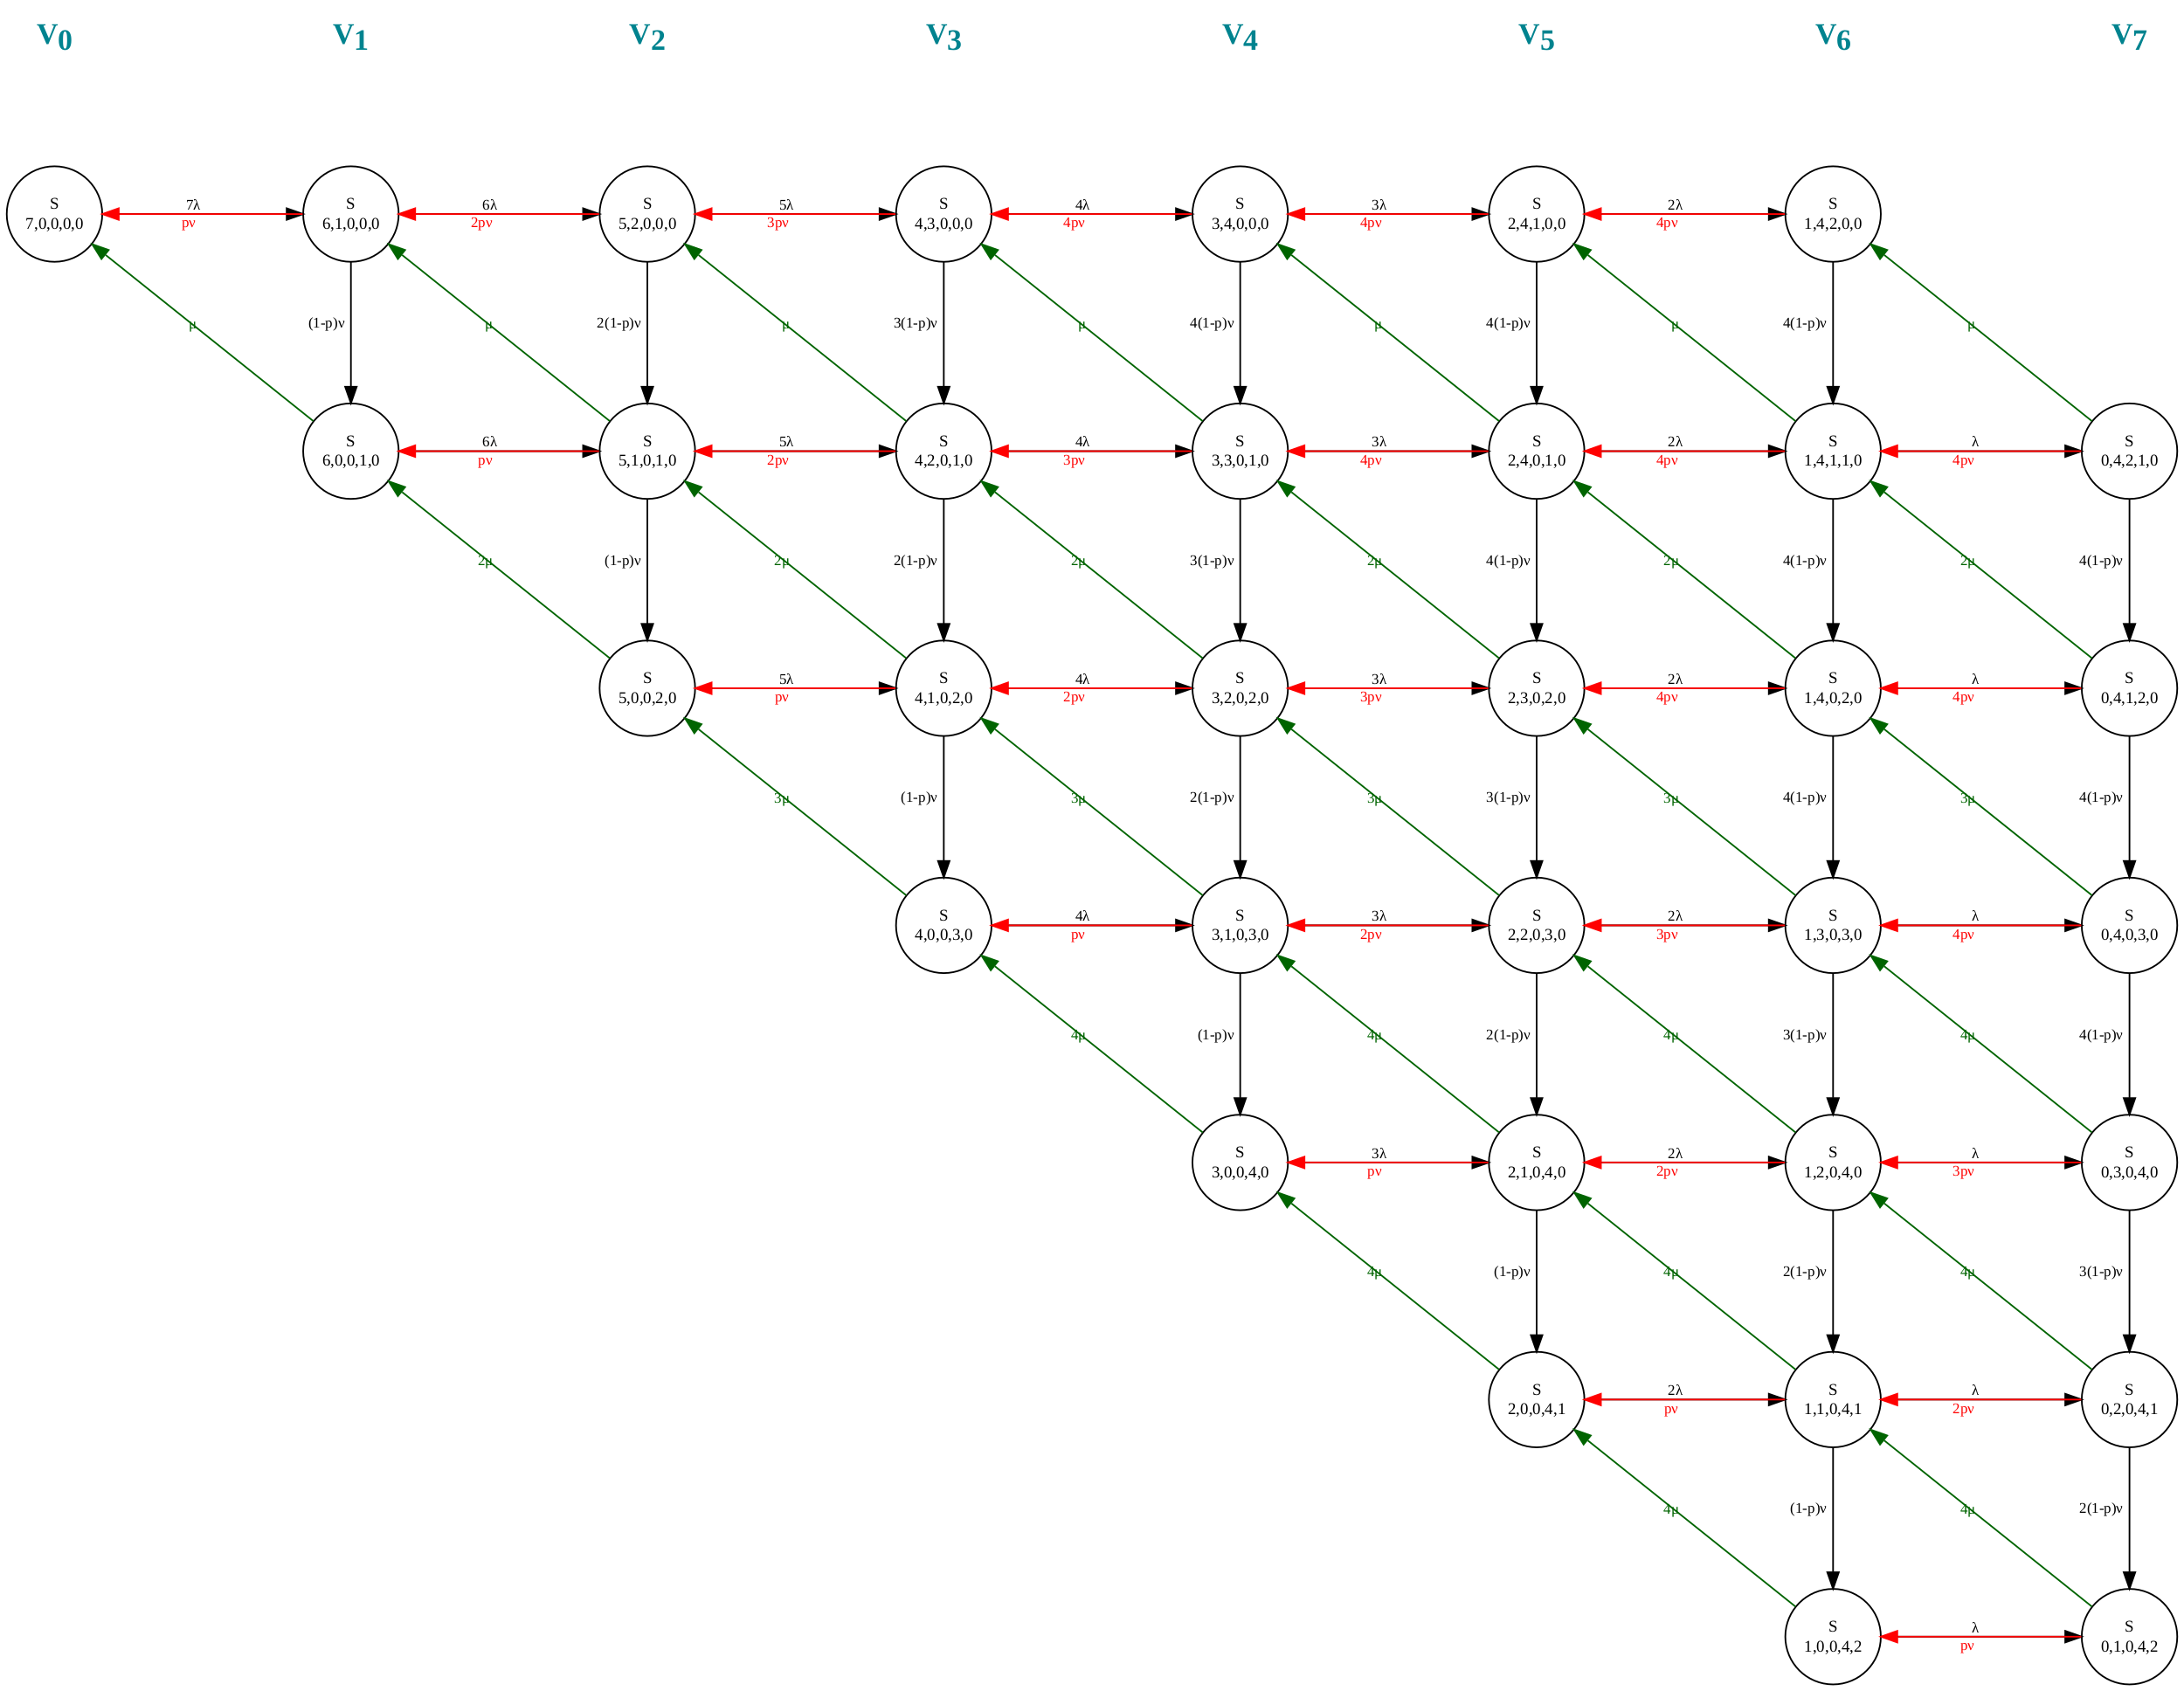


--- Точные вероятности укрупненных состояний (V_0 ... V_7) ---
     V_0      V_1      V_2      V_3      V_4      V_5      V_6      V_7 
0.000000 0.000006 0.000159 0.002197 0.018239 0.098290 0.334485 0.546623 
Сумма = 1 

2. Расчет коэффициентов gamma_i (усредненная интенсивность выхода из V_i):
   gamma_0    gamma_1    gamma_2    gamma_3    gamma_4    gamma_5    gamma_6 
0.00000000 0.05813842 0.11627685 0.17441527 0.23255370 0.27131264 0.29899761 
   gamma_7 
0.34883054 

3. Граф макро-состояний (Символьный вид):


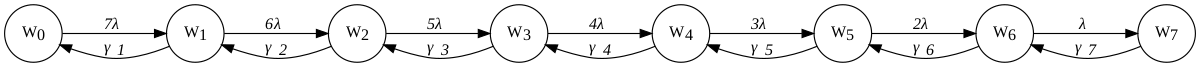


4. Приближенные вероятности (решение СЛАУ):
   P^v_0    P^v_1    P^v_2    P^v_3    P^v_4    P^v_5    P^v_6    P^v_7 
0.000000 0.000002 0.000068 0.001172 0.012201 0.081680 0.330780 0.574097 

5. Сравнение Точных и Приближенных вероятностей:
  Состояние Точная_вероятность Приближенная Ошибка
1       V_0            0.00000      0.00000     0%
2       V_1            0.00001      0.00000     0%
3       V_2            0.00016      0.00007  0.01%
4       V_3            0.00220      0.00117   0.1%
5       V_4            0.01824      0.01220   0.6%
6       V_5            0.09829      0.08168  1.66%
7       V_6            0.33449      0.33078  0.37%
8       V_7            0.54662      0.57410  2.75%


In [52]:
# --- РАСЧЕТ ВЕРОЯТНОСТЕЙ УКРУПНЕННЫХ СОСТОЯНИЙ (ВЕРТИКАЛЬНОЕ) ---

library(DiagrammeR)
library(DiagrammeRsvg)
library(rsvg)
library(IRdisplay)

# Исходные данные
K <- 7; N <- 4; M <- 4; m1 <- 2; m2 <- 2

states <- list()
edges_list <- list()

add_state <- function(k, n, q1, m, q2) {
  name <- paste0("S_", k, "_", n, "_", q1, "_", m, "_", q2)
  label <- paste0("S\n", k, ",", n, ",", q1, ",", m, ",", q2)
  if (!(name %in% names(states))) {
    # Для ИДЕАЛЬНОЙ сетки вертикального укрупнения:
    # X = сколько всего заявок в системе (K - k)
    # Y = сколько заявок на сервере (m + q2)
    v_sys <- K - k
    w_serv <- m + q2

    x_pos <- v_sys * 2.5
    y_pos <- -w_serv * 2.0

    states[[name]] <<- list(k=k, n=n, q1=q1, m=m, q2=q2, label=label, name=name, v_sys=v_sys, x=x_pos, y=y_pos)
    return(TRUE)
  }
  return(FALSE)
}

queue <- list(c(K, 0, 0, 0, 0))
add_state(K, 0, 0, 0, 0)
head <- 1

while(head <= length(queue)) {
  curr <- queue[[head]]; head <- head + 1
  k <- curr[1]; n <- curr[2]; q1 <- curr[3]; m <- curr[4]; q2 <- curr[5]
  curr_name <- paste0("S_", k, "_", n, "_", q1, "_", m, "_", q2)
  tot_AV <- n + q1; tot_MS <- m + q2

  if (k > 0 && tot_AV < (N + m1)) {
    nn <- ifelse(n < N, n + 1, n); nq1 <- ifelse(n == N, q1 + 1, q1)
    if (add_state(k-1, nn, nq1, m, q2)) queue <- append(queue, list(c(k-1, nn, nq1, m, q2)))
    edges_list <- c(edges_list, sprintf('"%s" -> "%s" [label="%s"];', curr_name, paste0("S_", k-1, "_", nn, "_", nq1, "_", m, "_", q2), ifelse(k > 1, paste0(k, "λ"), "λ")))
  }
  if (tot_AV > 0) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    if (add_state(k+1, nn, nq1, m, q2)) queue <- append(queue, list(c(k+1, nn, nq1, m, q2)))
    edges_list <- c(edges_list, sprintf('"%s" -> "%s" [label="%s", color="red", fontcolor="red"];', curr_name, paste0("S_", k+1, "_", nn, "_", nq1, "_", m, "_", q2), ifelse(n > 1, paste0(n, "pν"), "pν")))
  }
  if (tot_AV > 0 && tot_MS < (M + m2)) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    nm <- ifelse(m < M, m + 1, m); nq2 <- ifelse(m == M, q2 + 1, q2)
    if (add_state(k, nn, nq1, nm, nq2)) queue <- append(queue, list(c(k, nn, nq1, nm, nq2)))
    edges_list <- c(edges_list, sprintf('"%s" -> "%s" [label="%s"];', curr_name, paste0("S_", k, "_", nn, "_", nq1, "_", nm, "_", nq2), ifelse(n > 1, paste0(n, "(1-p)ν"), "(1-p)ν")))
  }
  if (tot_MS > 0) {
    nm <- ifelse(q2 > 0, m, m - 1); nq2 <- ifelse(q2 > 0, q2 - 1, 0)
    if (add_state(k+1, n, q1, nm, nq2)) queue <- append(queue, list(c(k+1, n, q1, nm, nq2)))
    edges_list <- c(edges_list, sprintf('"%s" -> "%s" [label="%s", color="darkgreen", fontcolor="darkgreen"];', curr_name, paste0("S_", k+1, "_", n, "_", q1, "_", nm, "_", nq2), ifelse(m > 1, paste0(m, "μ"), "μ")))
  }
}

# --- ПОСТРОЕНИЕ ГРАФА ---
graph_str <- "digraph G {\n  layout=neato;\n  splines=true;\n  overlap=false;\n  node [shape=circle, width=0.8, fixedsize=true, fontsize=10, style=filled, fillcolor=white];\n  edge [fontsize=9];\n"

for (name in names(states)) {
  s <- states[[name]]
  graph_str <- paste0(graph_str, sprintf('  "%s" [label="%s", pos="%f,%f!"];\n', name, s$label, s$x, s$y))
}

# Добавляем подписи V_i сверху над каждым столбцом
clusters_list_v <- list()
for (v in 0:K) {
  nodes_in_v <- names(states)[sapply(names(states), function(s_name) states[[s_name]]$v_sys == v)]
  if (length(nodes_in_v) > 0) {
    clusters_list_v[[as.character(v)]] <- nodes_in_v
    graph_str <- paste0(graph_str, sprintf('  "V_label_%d" [shape=none, label=<<font color="#00838F" point-size="18"><b>V<SUB>%d</SUB></b></font>>, pos="%f,1.5!"];\n', v, v, v*2.5))
  }
}

graph_str <- paste0(graph_str, paste(edges_list, collapse="\n  "), "\n}")

g <- grViz(graph_str)

# Save the PNG to a file first, then display that file.
png_file_path <- "graph_vertical.png"
rsvg_png(charToRaw(export_svg(g_macro)), file="macro_graph.png", width=1500, height=3300)
display_png(file=png_file_path)

# --- РАСЧЕТ ТОЧНЫХ ВЕРОЯТНОСТЕЙ ---
cat("\n--- Точные вероятности укрупненных состояний (V_0 ... V_7) ---\n")
P_V_exact <- rep(0, K + 1)
names(P_V_exact) <- paste0("V_", 0:K)

# Собираем кластеры V (v = K - k, то есть количество заявок внутри системы)
clusters_list_v <- list()
for (v in 0:K) {
  clusters_list_v[[as.character(v)]] <- names(states)[sapply(names(states), function(s_name) states[[s_name]]$k == (K - v))]
}

for (name in names(P)) {
  parts <- strsplit(name, "_")[[1]]
  k_val <- as.numeric(parts[2])
  v <- K - k_val
  P_V_exact[paste0("V_", v)] <- P_V_exact[paste0("V_", v)] + P[[name]]
}
print(round(P_V_exact, 6))
cat("Сумма =", sum(P_V_exact), "\n\n")


cat("2. Расчет коэффициентов gamma_i (усредненная интенсивность выхода из V_i):\n")

# Re-assign numeric values for lambda, mu, nu, p
# These values are taken from cell 5fd4ef6b-9a54-4cca-9124-32b3e2574c09
lambda <- 0.6054255
mu <- 0.08142403
nu <- 0.4713214
p <- 0.07394703

gamma_v <- rep(0, K + 1)
names(gamma_v) <- paste0("gamma_", 0:K)

for (v in 1:K) { # Из V_0 выхода нет (система пуста)
  nodes_in_v <- clusters_list_v[[as.character(v)]]
  if (length(nodes_in_v) > 0) {
    sum_rate <- 0
    for (node in nodes_in_v) {
      s <- states[[node]]
      # Интенсивность возврата = (найден вирус) + (обслужено сервером)
      sum_rate <- sum_rate + (s$n * p * nu + s$m * mu)
    }
    # Простое усреднение по количеству состояний в кластере (как в оригинальном решении)
    gamma_v[paste0("gamma_", v)] <- sum_rate / length(nodes_in_v)
  }
}
print(gamma_v)
cat("\n")

cat("3. Граф макро-состояний (Символьный вид):\n")
# Настраиваем красивые шрифты и отступы
macro_graph_v <- "digraph MacroV {
  rankdir=LR;
  ranksep=1.0;
  node [shape=circle, width=0.7, fixedsize=true, fontsize=14, fontname=\"Times-Roman\"];
  edge [fontsize=14, fontname=\"Times-Italic\"];\n"

for (v in 0:K) {
  # HTML-форматирование для красивых индексов W_0, W_1...
  macro_graph_v <- paste0(macro_graph_v, sprintf('  "V%d" [label=<W<SUB>%d</SUB>>];\n', v, v))
}

for (v in 0:(K-1)) {
  # Переход вправо (сверху): 7λ, 6λ ... λ
  rate_right <- ifelse((K-v) == 1, "&lambda;", paste0(K-v, "&lambda;"))
  macro_graph_v <- paste0(macro_graph_v, sprintf('  "V%d" -> "V%d" [label=<%s>];\n', v, v+1, rate_right))

  # Переход влево (снизу): γ1, γ2 ... γ7
  macro_graph_v <- paste0(macro_graph_v, sprintf('  "V%d" -> "V%d" [label=<&gamma;<SUB>%d</SUB>>];\n', v+1, v, v+1))
}
macro_graph_v <- paste0(macro_graph_v, "}")

g_macro_v <- grViz(macro_graph_v)
rsvg_png(charToRaw(export_svg(g_macro)), file="macro_graph.png", width=2000, height=300)
display_png(file="macro_graph_v.png")

cat("\n4. Приближенные вероятности (решение СЛАУ):\n")
num_V <- K + 1
Q_macro_v <- matrix(0, nrow=num_V, ncol=num_V)

for (v in 0:K) {
  if (v < K) { # Переход V_v -> V_{v+1}
    Q_macro_v[v+1, v+2] <- (K - v) * lambda
  }
  if (v > 0) { # Переход V_v -> V_{v-1}
    Q_macro_v[v+1, v] <- as.numeric(unname(gamma_v[v+1]))
  }
}
for(i in 1:num_V) Q_macro_v[i,i] <- -sum(Q_macro_v[i, -i])

A_v <- t(Q_macro_v)
b_v <- rep(0, num_V)
A_v[num_V, ] <- 1; b_v[num_V] <- 1
P_V_approx <- solve(A_v, b_v)
names(P_V_approx) <- paste0("P^v_", 0:K)

print(round(P_V_approx, 6))


cat("\n5. Сравнение Точных и Приближенных вероятностей:\n")
comparison_v <- data.frame(
  Состояние = paste0("V_", 0:K),
  Точная_вероятность = round(P_V_exact, 5),
  Приближенная = round(P_V_approx, 5),
  Ошибка = paste0(round(abs(P_V_exact - P_V_approx) * 100, 2), "%")
)
rownames(comparison_v) <- NULL
print(comparison_v)

### Исследование мин. времени пребывания в системе

Исследуем, при каких значениях $𝑚1, 𝑚2$ обеспечивается минимальное время пребывания заявки в системе с сохранением на заданном уровне абсолютной пропускной способности.

In [49]:
# --- Исследование мин. времени пребывания в системе (через simmer) ---

library(simmer)
library(dplyr)

# Исходные данные для Варианта 19
K <- 7
M <- 4
N <- 4
lambda <- 0.6054255
mu <- 0.08142403
nu <- 0.4713214
p <- 0.07394703
m1_base <- 2
m2_base <- 2

set.seed(21)

# Функция симуляции
simulate_system <- function(K, M, N, lambda, mu, nu, p, m1, m2, SIM_TIME) {
  env <- simmer("lab06_opt")

  virus_traj <- trajectory("virus_exit") %>%
    set_attribute("exit_type", 1) %>%
    set_attribute("exit_time", function() now(env))

  clean_traj <- trajectory("clean_path") %>%
    seize("server", 1, continue = FALSE) %>%
    timeout(function() rexp(1, rate = mu)) %>%
    release("server", 1) %>%
    set_attribute("exit_type", 2) %>%
    set_attribute("exit_time", function() now(env))

  programmer_traj <- trajectory("programmer_cycle") %>%
    timeout(function() rexp(1, rate = lambda)) %>%
    set_attribute("enter_time", function() now(env)) %>%
    seize("antivirus", 1, continue = FALSE) %>%
    timeout(function() rexp(1, rate = nu)) %>%
    release("antivirus", 1) %>%
    branch(
      option = function() ifelse(runif(1) < p, 1, 2),
      continue = c(TRUE, TRUE),
      virus_traj,
      clean_traj
    ) %>%
    rollback(7)

  env %>%
    add_resource("antivirus", capacity = N, queue_size = m1) %>%
    add_resource("server", capacity = M, queue_size = m2)

  for (i in 1:K) {
    env %>%
      add_generator(paste0("programmer_", i, "_"), programmer_traj, at(0), mon = 2)
  }

  env %>% run(until = SIM_TIME)

  attr <- get_mon_attributes(env)

  enter_df <- attr %>%
    filter(key == "enter_time") %>%
    group_by(name) %>% mutate(cycle = row_number()) %>%
    ungroup() %>% transmute(name, cycle, enter_time = value)

  exit_time_df <- attr %>%
    filter(key == "exit_time") %>%
    group_by(name) %>% mutate(cycle = row_number()) %>%
    ungroup() %>% transmute(name, cycle, exit_time = value)

  cycles_df <- enter_df %>% inner_join(exit_time_df, by = c("name", "cycle")) %>%
    mutate(time_in_system = exit_time - enter_time)

  T_sys_exp <- mean(cycles_df$time_in_system)
  abs_throughput_exp <- nrow(cycles_df) / SIM_TIME

  return(list(T_sys_exp = T_sys_exp, abs_throughput_exp = abs_throughput_exp))
}

cat("--- Исходные параметры (m1=2, m2=2) ---
")
result <- simulate_system(K, M, N, lambda, mu, nu, p, m1_base, m2_base, 200000)
cat(sprintf("W = %f | A = %f\n\n", result$T_sys_exp, result$abs_throughput_exp))

# --- Исследование m1 ---
cat("--- Перебор очереди антивируса (m1) от 1 до 15 (m2 фиксировано = 2) ---
")
for (m1_val in 1:15) {
  res <- simulate_system(K, M, N, lambda, mu, nu, p, m1_val, m2_base, 200000)
  cat(sprintf("m1 = %2d | W = %f | A = %f\n", m1_val, res$T_sys_exp, res$abs_throughput_exp))
}

# --- Исследование m2 ---
cat("\n--- Перебор очереди сервера (m2) от 1 до 15 (m1 фиксировано = 2) ---
")
for (m2_val in 1:15) {
  res <- simulate_system(K, M, N, lambda, mu, nu, p, m1_base, m2_val, 200000)
  cat(sprintf("m2 = %2d | W = %f | A = %f\n", m2_val, res$T_sys_exp, res$abs_throughput_exp))
}

--- Исходные параметры (m1=2, m2=2) ---
W = 16.173982 | A = 0.336545

--- Перебор очереди антивируса (m1) от 1 до 15 (m2 фиксировано = 2) ---
m1 =  1 | W = 14.742381 | A = 0.317225
m1 =  2 | W = 16.017010 | A = 0.339555
m1 =  3 | W = 16.215173 | A = 0.335755
m1 =  4 | W = 16.215179 | A = 0.335660
m1 =  5 | W = 16.261546 | A = 0.334950
m1 =  6 | W = 16.258173 | A = 0.335240
m1 =  7 | W = 16.118983 | A = 0.337535
m1 =  8 | W = 16.184828 | A = 0.336395
m1 =  9 | W = 16.213141 | A = 0.335880
m1 = 10 | W = 16.178352 | A = 0.336460
m1 = 11 | W = 16.162230 | A = 0.336745
m1 = 12 | W = 16.132835 | A = 0.337350
m1 = 13 | W = 16.289470 | A = 0.334255
m1 = 14 | W = 16.189180 | A = 0.336155
m1 = 15 | W = 16.205177 | A = 0.336005

--- Перебор очереди сервера (m2) от 1 до 15 (m1 фиксировано = 2) ---
m2 =  1 | W = 14.420149 | A = 0.311280
m2 =  2 | W = 16.198749 | A = 0.336290
m2 =  3 | W = 17.953654 | A = 0.348460
m2 =  4 | W = 18.502313 | A = 0.347360
m2 =  5 | W = 16.209040 | A = 0.337945
m2 =  6 

 *"В ходе имитационного моделирования мы изменяли длины очередей $m_1$ и $m_2$ от 1 до 15. Как видно из результатов, поскольку система является замкнутой с конечным числом источников ($K=7$), дальнейшее увеличение очередей после определенного порога не приводит к изменению характеристик системы. Пропускная способность (A) и среднее время в системе (W) стабилизируются. Минимальное время пребывания заявки достигается при значениях **W = 14.420149** (при $m_1=2, m_2=1$), при этом пропускная способность сохраняется на заданном уровне (A = 0.311280)."*